# Backtester

Run all cells, then press Enter for the pendulum study or type C to test your own rules: one ticker, several, a ready-made list (forex pairs, S&P 500 stocks) or a shared portfolio. The README explains the study and the results.

## Setup

In [1]:
import ast
import math
import re
import textwrap
from datetime import date
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
try:
    import yfinance as yf
except ImportError:
    yf = None #if yfinance not installed -> program doesn't crash and only complains when you try download data

__version__ = "2.0.0"

TRADING_DAYS = 252 #rough number of days market is open per year
WARMUP_DAYS = 500 #extra calendar days downloaded before start date -> more on this in load_many
DOWNLOAD_CHUNK = 50 #tickers asked from Yahoo in one request
BAD_TICK_SIZE = 8 #a forex close this many times the usual daily move, undone the next day, is a bad quote
BAD_TICK_UNDONE = 0.25 #"undone" = the next close is back within this share of the jump
MAX_DETAILED = 5 #with more tickers than this, each gets one quick backtest and the full checks run on request
SP500_FUND = "SPY" #what "compare to the S&P 500" buys: a fund that holds the index and pays its dividends
KELLY_FRACTION = 0.5 #a smart portfolio bets half of what the Kelly formula says, because its inputs are only estimates
KELLY_PRIOR = 100 #a ticker's own record is mixed with this many signals' worth of the record of all tickers together
KELLY_MIN_SIGNALS = 20 #signals that must have closed before the record is used at all
OVERLAP_DAYS = 60 #days of price moves used to see which positions move together
BIG_PORTFOLIO = 50 #with more tickers than this, a smart portfolio waits a few days between working out its split
REALLOCATE_DAYS = 21 #a smart portfolio works its split out again at least this often, and measures overlap this often
RANDOM_RUNS = 300 #random strategies benchmark creates to compare against strategy
SENSITIVITY_STEPS = [0.5, 0.75, 1.0, 1.25, 1.5]
TUNE_STEPS = [0.8, 0.9, 1.0, 1.1, 1.25]  # how far each number is nudged when searching for better rules
TUNE_PASSES = 3
MAX_MARKERS = 200
RULE_SIDES = [("buy", "buy_rule"), ("sell", "sell_rule"), ("short", "short_rule"), ("cover", "cover_rule")]
# the settings that decide what to hold. The rest decide what it costs and earns
PLAN_KEYS = ("buy_rule", "sell_rule", "short_rule", "cover_rule", "size_rule", "position_pct",
             "target_vol_pct", "stop_loss_pct", "take_profit_pct", "delay_days")

# every pair of the eight most traded currencies, named the way the market quotes them
_CURRENCIES = ["EUR", "GBP", "AUD", "NZD", "USD", "CAD", "CHF", "JPY"]
FOREX_ALL = [f"{a}{b}=X" for i, a in enumerate(_CURRENCIES) for b in _CURRENCIES[i + 1:]]
FOREX_MAJORS = [pair for pair in FOREX_ALL if "USD" in pair]
UNIVERSES = {"FOREX": "Major forex pairs (7)", "FOREX28": "Major and cross forex pairs (28)",
             "SP500": "S&P 500 stocks (about 500)"}
try:
    DATA_DIR = Path(__file__).parent / "data"
except NameError:  # in the notebook
    DATA_DIR = Path("data")

# The pendulum written in the rule language (small swings, with friction):
#   THETA = (PRICE - MA60) / STD60             distance from equilibrium, in standard deviations
#   V     = THETA - THETA[1]                    velocity, one day per step
#   TURN  = 0.8 * SQRT(THETA^2 + V^2 / 0.01)    where the swing turns: energy ½v² + ½ω²θ² with ω² = 0.01
#                                               gives the amplitude, of which friction lets it keep 80%
_T = "(PRICE - MA60) / STD60"
_T1 = "(PRICE[1] - MA60[1]) / STD60[1]"
_T2 = "(PRICE[2] - MA60[2]) / STD60[2]"
_TURN = f"0.8 * SQRT(({_T}) ^ 2 + ({_T} - {_T1}) ^ 2 / 0.01)"

DEFAULT_STUDY = {
    "physics": """
Default study: does EUR/USD move like a pendulum?

The 60-day average is the bottom of the swing, and price is the pendulum.
  θ   how far price is from its 60-day average, in standard deviations
  v   how much θ changed since yesterday
  ω²  0.01, how strongly price is pulled back (a swing of about 63 days)

For small swings a pendulum follows  d²θ/dt² = -ω²θ.  Its energy ½v² + ½ω²θ² tells you how far
the swing will go:  amplitude = √(θ² + v²/ω²).  Markets aren't a perfect pendulum, so friction
lets the swing keep only 80% of that, and news can knock it off course completely.

Buy when a swing bottoms out below -1.5 and sell when it reaches 80% of the predicted
amplitude on the other side. If price runs past 3 standard deviations, the average has
probably moved, so get out. Shorts are the mirror image.
Rules were set using 2005-2015 and tested on 2016 onwards.""",
    "tickers": ["EURUSD=X"],
    "start": "2005-01-01",
    "end": date.today().isoformat(),
    "split_date": "2016-01-01",
    "settings": {
        "buy_rule": f"BUY IF {_T1} < {_T2} AND {_T} > {_T1} AND {_T} < -1.5",
        "sell_rule": f"SELL IF {_T} > {_TURN} OR {_T} < -3",
        "short_rule": f"SHORT IF {_T1} > {_T2} AND {_T} < {_T1} AND {_T} > 1.5",
        "cover_rule": f"COVER IF -({_T}) > {_TURN} OR {_T} > 3",
        "size_rule": "",
        "initial": 10000,
        "cost_pct": 0.02,
        "short_fee_pct": 0.0,
        "position_pct": 100,
        "target_vol_pct": None,
        "rebalance_pct": 10,
        "stop_loss_pct": None,
        "take_profit_pct": None,
    },
}

CUSTOM_DEFAULTS = {
    "tickers": ["EURUSD=X"],
    "start": "2005-01-01",
    "split_date": "2016-01-01",
    "buy_rule": "BUY IF PRICE > MA200",
    "sell_rule": "SELL IF PRICE < MA200",
    "short_rule": "SHORT IF PRICE < MA200",
    "cover_rule": "COVER IF PRICE > MA200",
    "initial": 10000,
    "cost_pct": 0.02,
    "short_fee_pct": 0.0,
    "position_pct": 100,
    "rebalance_pct": 10,
    "carry_pct": 0.0,
    "cash_rate_pct": 0.0,
    "max_weight_pct": 20,
}

HELP = """
INDICATORS (replace N with a number, at least 2)
  PRICE, MAN, EMAN, STDN, RSIN, ZSCOREN, VOLN (annual %), HIGHN / LOWN (previous N days),
  RETURN_ND (%), DIST_MAN / DIST_HIGHN / DIST_LOWN (%), MACD, MACD_SIGNAL, DRAWDOWN (%)

OPERATORS   >  <  >=  <=  CROSSES_ABOVE  CROSSES_BELOW      combine with AND / OR

FORMULAS (both sides of a comparison can be any formula)
  + - * / ^ and brackets          (PRICE - MA60) / STD60 < -1.5
  [n] = n days ago                PRICE > PRICE[1]
  SIN COS TAN ASIN ACOS ATAN ABS SQRT LOG EXP      ABS(PRICE - MA20) > STD20
  STDN = typical distance of price from its N-day average

RULES
  BUY IF ZSCORE20 < -2
  SELL IF ZSCORE20 > 0
  BUY IF RSI14 < 30 AND PRICE > MA200
  SELL IF MA20 CROSSES_BELOW MA50 OR RSI14 > 75
  BUY IF PRICE < PRICE[1]    price fell today
  SELL IF NONE

SHORTING (optional)
  SHORT IF PRICE < MA200     bet on a fall
  COVER IF PRICE > MA200     close the short
  An opposite signal flips the position directly (long -> short or back).
  Sizing rules apply to longs only.

STOP LOSS AND TAKE PROFIT (optional, % from the price the trade was opened at)
  They work in both directions and fill during the day at their level, or at the open if the
  price jumped past it overnight. After one of them closes a trade, the rule has to switch off
  and on again before it enters in that direction again.

SIZING (optional, how much to hold while the buy rule is active)
  SIZE BY ZSCORE20 FROM -1 TO -3     0% at -1, 100% at -3, in between scales linearly
  SIZE BY RSI14 FROM 40 TO 20        more RSI weakness, bigger position
  Target volatility, e.g. 15         hold less when the asset is jumpy

TICKERS
  One or more Yahoo symbols: EURUSD=X, SPY, AAPL
  Or a ready-made list: FOREX (7 major pairs), FOREX28 (majors and crosses), SP500 (about 500 stocks)
  Several tickers are tested one by one, each with the full starting money, or as one portfolio
  that shares it. A portfolio splits its money in one of three ways:
    smart    more to the tickers where the rule's past signals made a profit more often and
             lost less (the Kelly formula, at half strength), less to positions that move
             together, never more than the account holds
    equal    the same slice for every ticker
    spread   shared equally by the tickers that have a position open

MODES
  Default    press Enter at the start: the pendulum study
  Quick      asks only for tickers, dates, rules and cost; everything else uses defaults.
             Shows your rule vs buy & hold, when you were in and out, what went wrong.
  Advanced   asks for every setting and adds a train/test split, 300 random strategies,
             parameter sensitivity and a search for better numbers in your rules.
             With more than 5 tickers, each gets one quick backtest instead.
"""

QUICK_DEFAULTS = {
    "size_rule": "",
    "initial": 10000,
    "position_pct": 100,
    "target_vol_pct": None,
    "rebalance_pct": 10,
    "stop_loss_pct": None,
    "take_profit_pct": None,
    "short_fee_pct": 0.0,
    "carry_pct": 0.0,
    "cash_rate_pct": 0.0,
}

## Data

In [2]:
def is_forex(ticker):
    return ticker.upper().endswith("=X")


def universe(name):
    key = name.strip().upper()
    if key == "FOREX":
        return list(FOREX_MAJORS)
    if key == "FOREX28":
        return list(FOREX_ALL)
    if key == "SP500":
        # today's members, so the companies that dropped out of the index over the years are missing
        return pd.read_csv(DATA_DIR / "sp500.csv")["ticker"].tolist()
    raise ValueError(f"unknown list '{name}'")


def as_tickers(text):
    # "eurusd=x, spy" -> ["EURUSD=X", "SPY"]. The name of a ready-made list stands for its tickers
    tickers = []
    for part in text.split(","):
        part = part.strip().upper()
        if part:
            tickers += universe(part) if part in UNIVERSES else [part]
    return list(dict.fromkeys(tickers))


def _bad_ticks(close):
    # a quote that jumps far outside the usual daily move and is back the next day never traded.
    # "Usual" is measured on the days around it, so the real jumps of a crisis are left alone
    c = close.to_numpy(dtype=float)
    if len(c) < 3:
        return close.index[:0]
    moves = np.abs(c[1:] / c[:-1] - 1)  # moves[i] is the move into bar i + 1
    bad = []
    for t in range(1, len(c) - 1):
        jump, after = c[t] / c[t - 1] - 1, c[t + 1] / c[t - 1] - 1
        if abs(jump) < 0.01 or abs(after) > BAD_TICK_UNDONE * abs(jump):
            continue
        nearby = np.concatenate([moves[max(0, t - 11):t - 1], moves[t + 1:t + 11]])  # without the jump and its undoing
        if len(nearby) >= 5 and abs(jump) > BAD_TICK_SIZE * np.median(nearby) > 0:
            bad.append(t)
    return close.index[bad]


def clean_prices(df, ticker=""):
    # Yahoo's columns -> Open, High, Low, Close, Dividends, with the faults that would move a
    # backtest repaired. What was changed is listed in the result's .attrs["notes"]
    out = df[["Open", "High", "Low", "Close"]].astype(float)
    out["Dividends"] = 0.0
    for name in ("Dividends", "Capital Gains"):  # funds pay out capital gains the same way
        if name in df.columns:
            out["Dividends"] += df[name].fillna(0.0).astype(float)
    out = out.dropna()
    out = out[(out[["Open", "High", "Low", "Close"]] > 0).all(axis=1)]
    if out.empty:
        raise ValueError("no data found")
    notes = []
    if is_forex(ticker):
        # forex quotes come from dealers, not an exchange, and Yahoo's history has two faults.
        # Some closes are plainly wrong (EUR/USD at 1.49 between two days at 1.28), and since
        # about 2011 the open, high and low belong to the day after the close they are listed
        # with. Only the closes line up over the whole history, so each bar is rebuilt from them:
        # a currency trades around the clock, so the last close is the price you can trade at next
        bad = _bad_ticks(out["Close"])
        if len(bad):
            out = out.drop(bad)
            shown = ", ".join(str(day.date()) for day in bad[:5]) + (" ..." if len(bad) > 5 else "")
            notes.append(f"Removed {len(bad)} bad quote{'s' if len(bad) > 1 else ''} ({shown})")
        out["Open"] = out["Close"].shift(1).fillna(out["Open"])
        out["High"] = out[["Open", "Close"]].max(axis=1)
        out["Low"] = out[["Open", "Close"]].min(axis=1)
        notes.append("Forex: each day opens at the previous close, and stops are checked on closes")
    else:
        out["High"] = out[["Open", "High", "Close"]].max(axis=1)
        out["Low"] = out[["Open", "Low", "Close"]].min(axis=1)
    out.attrs["notes"] = notes
    return out


def load_many(tickers, start, end, progress=None):
    # returns ({ticker: prices}, [(ticker, why it was skipped)]). Prices are not adjusted for
    # dividends: they are what was really quoted, and dividends are paid into the account instead
    if yf is None:
        raise ImportError("yfinance is not installed. Run: pip install yfinance")
    tickers = list(tickers)
    buffer_start = (pd.Timestamp(start) - pd.Timedelta(days=WARMUP_DAYS)).strftime("%Y-%m-%d") #start date 500 days earlier than yours -> enough history for indicators such as MA200
    data, failed = {}, []

    def download(chunk):
        raw = yf.download(chunk, start=buffer_start, end=end, auto_adjust=False, actions=True,
                          progress=False, group_by="ticker", threads=True)
        missing = []
        for ticker in chunk:
            try:
                data[ticker] = clean_prices(raw[ticker], ticker)
            except (KeyError, ValueError, TypeError):
                missing.append(ticker)
        return missing

    for i in range(0, len(tickers), DOWNLOAD_CHUNK):
        missing = download(tickers[i:i + DOWNLOAD_CHUNK])
        if missing:
            missing = download(missing)  # in a big batch Yahoo sometimes drops a ticker that does exist
        failed += [(ticker, "no data found") for ticker in missing]
        if progress:
            progress(min(i + DOWNLOAD_CHUNK, len(tickers)), len(tickers))
    return {ticker: data[ticker] for ticker in tickers if ticker in data}, failed


def load_prices(ticker, start, end):
    data, failed = load_many([ticker], start, end)
    if failed:
        raise ValueError(f"no data found for {ticker}")
    return data[ticker]


def data_notes(prices):
    return list(prices.attrs.get("notes", []))

## Indicators

In [3]:
def _rsi(close, window):
    delta = close.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.ewm(alpha=1 / window, adjust=False, min_periods=window).mean()
    avg_loss = loss.ewm(alpha=1 / window, adjust=False, min_periods=window).mean()
    rsi = 100 - 100 / (1 + avg_gain / avg_loss)
    return rsi.where(avg_loss != 0, 100.0)


def _zscore(close, window):
    mean = close.rolling(window).mean()
    std = close.rolling(window).std()
    return (close - mean) / std


def _macd(close):
    return close.ewm(span=12, adjust=False).mean() - close.ewm(span=26, adjust=False).mean()


WINDOW_INDICATORS = [
    (r"(?:MA|SMA)(\d+)", lambda c, w: c.rolling(w).mean()),
    (r"EMA(\d+)",        lambda c, w: c.ewm(span=w, adjust=False, min_periods=w).mean()),
    (r"RSI(\d+)",        _rsi),
    (r"ZSCORE(\d+)",     _zscore),
    (r"VOL(\d+)",        lambda c, w: c.pct_change().rolling(w).std() * math.sqrt(TRADING_DAYS) * 100),
    (r"HIGH(\d+)",       lambda c, w: c.rolling(w).max().shift(1)),
    (r"LOW(\d+)",        lambda c, w: c.rolling(w).min().shift(1)),
    (r"RETURN_?(\d+)D",  lambda c, w: c.pct_change(w) * 100),
    (r"DIST_MA(\d+)",    lambda c, w: (c / c.rolling(w).mean() - 1) * 100),
    (r"STD(\d+)",        lambda c, w: c.rolling(w).std()),
    (r"DIST_HIGH(\d+)",  lambda c, w: (c / c.rolling(w).max().shift(1) - 1) * 100),
    (r"DIST_LOW(\d+)",   lambda c, w: (c / c.rolling(w).min().shift(1) - 1) * 100),
]


def get_indicator(name, close):
    n = name.upper()
    if n in ("PRICE", "CLOSE"):
        return close
    if n == "MACD":
        return _macd(close)
    if n == "MACD_SIGNAL":
        return _macd(close).ewm(span=9, adjust=False).mean()
    if n == "DRAWDOWN":
        peak = close.cummax()
        return (close - peak) / peak * 100
    for pattern, func in WINDOW_INDICATORS:
        match = re.fullmatch(pattern, n)
        if match:
            window = int(match.group(1))
            if window < 2:
                raise ValueError(f"window in {name} must be at least 2")
            return func(close, window)
    raise ValueError(f"unknown indicator '{name}'")

## Rules and formulas

In [4]:
FLIPPED = {">": "<", "<": ">", ">=": "<=", "<=": ">=",
           "CROSSES_ABOVE": "CROSSES_BELOW", "CROSSES_BELOW": "CROSSES_ABOVE"}


def _normalise(text):
    t = " ".join((text or "").strip().upper().split())
    return t.replace("CROSSES ABOVE", "CROSSES_ABOVE").replace("CROSSES BELOW", "CROSSES_BELOW")


COMPARISON = re.compile(r"CROSSES_ABOVE|CROSSES_BELOW|>=|<=|>|<")
FUNCTIONS = {"SIN": np.sin, "COS": np.cos, "TAN": np.tan, "ASIN": np.arcsin, "ACOS": np.arccos,
             "ATAN": np.arctan, "ABS": np.abs, "SQRT": np.sqrt, "LOG": np.log, "EXP": np.exp}


def parse_rule(text):
    t = re.sub(r"^(BUY|SELL|SHORT|COVER)\s+IF\s+", "", _normalise(text))
    if t in ("", "NONE"):
        return None
    groups = []
    for group_text in re.split(r"\s+OR\s+", t):
        conditions = []
        for cond_text in re.split(r"\s+AND\s+", group_text):
            match = COMPARISON.search(cond_text)
            if not match:
                raise ValueError(f"can't read '{cond_text}'. Use: FORMULA OPERATOR FORMULA, e.g. PRICE > MA200")
            left, right = cond_text[:match.start()].strip(), cond_text[match.end():].strip()
            if not left or not right:
                raise ValueError(f"'{cond_text}' needs something on both sides of {match.group()}")
            conditions.append((left, match.group(), right))
        groups.append(conditions)
    return groups


def evaluate(formula, close, cache=None):
    # turns text like "(PRICE - MA60) / STD60" into a series of values, one per day.
    # The text is parsed into a syntax tree and only the node types below are accepted, so nothing
    # a user types is ever executed. The cache keeps indicators and whole formulas that repeat
    cache = {} if cache is None else cache
    if ("formula", formula) in cache:
        return cache[("formula", formula)]
    try:
        tree = ast.parse(formula.replace("^", "**"), mode="eval").body
    except SyntaxError:
        raise ValueError(f"can't read the formula '{formula}'")

    def indicator(name):
        if name not in cache:
            cache[name] = get_indicator(name, close)
        return cache[name]

    def calc(node):
        if isinstance(node, ast.Constant) and isinstance(node.value, (int, float)):
            return float(node.value)
        if isinstance(node, ast.Name):
            return indicator(node.id)
        if isinstance(node, ast.Subscript) and isinstance(node.value, ast.Name):  # MA60[1] = yesterday
            days = node.slice.value if isinstance(node.slice, ast.Constant) else None
            if not isinstance(days, int) or days < 0:
                raise ValueError("use a whole number of days in brackets, e.g. PRICE[1]")
            return indicator(node.value.id).shift(days)
        if isinstance(node, ast.UnaryOp) and isinstance(node.op, (ast.USub, ast.UAdd)):
            value = calc(node.operand)
            return -value if isinstance(node.op, ast.USub) else value
        if isinstance(node, ast.BinOp):
            a, b = calc(node.left), calc(node.right)
            ops = {ast.Add: lambda: a + b, ast.Sub: lambda: a - b, ast.Mult: lambda: a * b,
                   ast.Div: lambda: a / b, ast.Pow: lambda: a ** b}
            if type(node.op) in ops:
                return ops[type(node.op)]()
        if isinstance(node, ast.Call) and isinstance(node.func, ast.Name) and node.func.id in FUNCTIONS:
            if len(node.args) != 1:
                raise ValueError(f"{node.func.id} takes one value, e.g. {node.func.id}(PRICE)")
            return FUNCTIONS[node.func.id](calc(node.args[0]))
        raise ValueError(f"can't read part of the formula '{formula}'")

    with np.errstate(all="ignore"):  # e.g. ACOS of a number outside -1..1 gives no answer (NaN)
        result = calc(tree)
    if not isinstance(result, pd.Series):
        result = pd.Series(result, index=close.index)
    cache[("formula", formula)] = result.replace([np.inf, -np.inf], np.nan)
    return cache[("formula", formula)]


def _condition(left, op, right, close, cache=None):
    a = evaluate(left, close, cache)
    b = evaluate(right, close, cache)
    valid = a.notna() & b.notna()
    if op == ">":
        result = a > b
    elif op == "<":
        result = a < b
    elif op == ">=":
        result = a >= b
    elif op == "<=":
        result = a <= b
    elif op == "CROSSES_ABOVE":
        result = (a > b) & (a.shift(1) <= b.shift(1))
    else:
        result = (a < b) & (a.shift(1) >= b.shift(1))
    return (result & valid).fillna(False).astype(bool)


def build_signal(rule_text, close, cache=None):
    # True on the days the rule fires: conditions joined by AND form a group, groups are joined by OR
    groups = parse_rule(rule_text)
    signal = pd.Series(False, index=close.index)
    if groups is None:
        return signal
    cache = {} if cache is None else cache
    for conditions in groups:
        group_signal = pd.Series(True, index=close.index)
        for left, op, right in conditions:
            group_signal &= _condition(left, op, right, close, cache)
        signal |= group_signal
    return signal


def flip_rule(rule_text):
    return " ".join(FLIPPED.get(token, token) for token in _normalise(rule_text).split())


def parse_size(text):
    t = _normalise(text)
    if t in ("", "NONE"):
        return None
    match = re.fullmatch(r"(?:SIZE\s+BY\s+)?(\S+)\s+FROM\s+(\S+)\s+TO\s+(\S+)", t)
    if not match:
        raise ValueError("use: SIZE BY INDICATOR FROM VALUE TO VALUE")
    low, high = float(match.group(2)), float(match.group(3))
    if low == high:
        raise ValueError("FROM and TO must be different")
    return match.group(1), low, high


def size_strength(size_rule, close):
    parsed = parse_size(size_rule)
    if parsed is None:
        return pd.Series(1.0, index=close.index)
    name, low, high = parsed
    values = get_indicator(name, close)
    return ((values - low) / (high - low)).clip(0, 1).fillna(0)


def _dummy_close():
    steps = np.random.default_rng(0).normal(0, 1, 400)
    return pd.Series(100 + np.cumsum(steps), index=pd.bdate_range("2000-01-03", periods=400))


def validate_rule(text):
    build_signal(text, _dummy_close())
    return text


def validate_size(text):
    size_strength(text, _dummy_close())
    return text

## Backtest engine

In [5]:
#
# A backtest has two steps. trade_plan turns one ticker's rules into what to hold after each close,
# without any money involved. simulate then trades those plans with real money, costs and interest.
# Because the plan does not depend on the money, the same code runs one ticker or a whole portfolio.

def _dividends(prices):
    if "Dividends" in prices.columns:
        return prices["Dividends"]
    return pd.Series(0.0, index=prices.index)


def _in_window(prices, start, end):
    return (prices.index >= pd.Timestamp(start)) & (prices.index < pd.Timestamp(end))


def _order_hit(held, entry, price_open, high, low, stop, gain):
    # a stop loss and a take profit rest in the market as orders. Each fills at its own level, or at
    # the open if the price jumped past it overnight. A daily bar does not say which came first
    # when both levels are inside its range, so the stop is assumed to: the worse case
    if stop is not None:
        stop_at = entry * (1 - held * stop)
        if held * (price_open - stop_at) <= 0:
            return price_open, "stop loss"
    if gain is not None:
        gain_at = entry * (1 + held * gain)
        if held * (price_open - gain_at) >= 0:
            return price_open, "take profit"
    worst, best = (low, high) if held > 0 else (high, low)
    if stop is not None and held * (worst - stop_at) <= 0:
        return stop_at, "stop loss"
    if gain is not None and held * (best - gain_at) >= 0:
        return gain_at, "take profit"
    return None


def trade_plan(prices, start, end, buy_rule, sell_rule, short_rule="", cover_rule="", size_rule="",
               position_pct=100.0, target_vol_pct=None, stop_loss_pct=None, take_profit_pct=None,
               delay_days=0):
    # Signals are worked out on the whole history, warm-up included, then cut to start..end.
    # Each day has three steps: at the open, the position wanted the evening before is in place;
    # during the day a stop or take profit may close it; at the close, the signals are read and
    # set what to hold tomorrow. delay_days makes every signal arrive that many days late, to
    # see how much a result depends on being filled straight away.
    close_all = prices["Close"]
    cache = {}  # the four rules usually share indicators and formulas, so work each out once
    buy_all = build_signal(buy_rule, close_all, cache)
    sell_all = build_signal(sell_rule, close_all, cache)
    short_all = build_signal(short_rule, close_all, cache)
    cover_all = build_signal(cover_rule, close_all, cache)
    strength_all = size_strength(size_rule, close_all)
    if target_vol_pct:
        vol = get_indicator("VOL20", close_all)
        vol_scale_all = (target_vol_pct / vol).clip(upper=1).fillna(0)
    else:
        vol_scale_all = pd.Series(1.0, index=close_all.index)
    if delay_days:
        buy_all, sell_all, short_all, cover_all = (signal.shift(delay_days, fill_value=False)
                                                   for signal in (buy_all, sell_all, short_all, cover_all))
        strength_all, vol_scale_all = strength_all.shift(delay_days).fillna(0), vol_scale_all.shift(delay_days).fillna(0)

    window = _in_window(prices, start, end)
    dates = prices.index[window]
    if len(dates) < 30:
        raise ValueError(f"only {len(dates)} trading days between {start} and {end}")
    opens = prices["Open"][window].tolist()
    highs = prices["High"][window].tolist()
    lows = prices["Low"][window].tolist()
    buy_sig = buy_all[window].tolist()
    sell_sig = sell_all[window].tolist()
    short_sig = short_all[window].tolist()
    cover_sig = cover_all[window].tolist()
    base = min(position_pct, 100) / 100
    long_size = (base * strength_all * vol_scale_all)[window].tolist()
    short_size = (base * vol_scale_all)[window].tolist()
    stop = stop_loss_pct / 100 if stop_loss_pct else None
    gain = take_profit_pct / 100 if take_profit_pct else None
    orders = stop is not None or gain is not None

    side, want = 0, 0.0  # side: 1 long, -1 short, 0 out. want: share of the money to hold, short if negative
    held, entry = 0, 0.0  # the position in place today and the price it was opened at
    waiting = 0  # after a stop or take profit: the side that may not be entered until its rule resets
    wants, reasons, exits = [], [], {}
    closed = []  # (day, % made per unit held) of every position the rules closed, before costs

    for i in range(len(dates)):
        # ---- at the open: the position wanted last night is in place ----
        now = (want > 0) - (want < 0)
        if now != held:
            if held:
                closed.append((i, held * (opens[i] / entry - 1)))
            held, entry = now, opens[i]

        # ---- during the day: a stop or take profit may close it ----
        exited, reason = 0, ""
        if orders and held != 0:
            hit = _order_hit(held, entry, opens[i], highs[i], lows[i], stop, gain)
            if hit:
                exits[i] = hit
                closed.append((i, held * (hit[0] / entry - 1)))
                exited = waiting = held
                side = held = 0

        # ---- at the close: signals for tomorrow ----
        if side == 1 and (sell_sig[i] or short_sig[i]):
            reason = "sell rule" if sell_sig[i] else "flipped to short"
        elif side == -1 and (cover_sig[i] or buy_sig[i]):
            reason = "cover rule" if cover_sig[i] else "flipped to long"
        if reason:
            exited, side = side, 0
        if waiting and not (buy_sig[i] if waiting == 1 else short_sig[i]):
            waiting = 0
        if side == 0:
            if buy_sig[i] and exited != 1 and waiting != 1:
                side = 1
            elif short_sig[i] and exited != -1 and waiting != -1:
                side = -1

        want = long_size[i] if side == 1 else -short_size[i] if side == -1 else 0.0
        if side != 0 and want == 0 and not exited:
            reason = "sized down to 0%"
        wants.append(want)
        reasons.append(reason)

    return {"dates": dates, "open": np.array(opens), "close": prices["Close"][window].to_numpy(dtype=float),
            "dividends": _dividends(prices)[window].to_numpy(dtype=float),
            "wants": np.array(wants), "reasons": reasons, "exits": exits, "closed": closed}


def _note_result(record, result):
    # record: [signals closed, winners, sum of the wins, sum of the losses]
    record[0] += 1
    if result > 0:
        record[1] += 1
        record[2] += result
    else:
        record[3] -= result


def expected_edge(own, everyone):
    # How likely is the next signal on this ticker to pay, and how much should be bet on it?
    # The only evidence is how the rule's earlier signals ended. A ticker's own record is short, so
    # it is mixed with KELLY_PRIOR signals' worth of the record of all tickers together: a ticker
    # with no history is treated as average, and one with a long history mostly speaks for itself.
    # The Kelly formula then gives the share of the money that grows it fastest in the long run:
    #     share = chance of a win / average loss - chance of a loss / average win
    # It is negative when the wins do not pay for the losses. Returns (chance, win, loss, share),
    # or None while too few signals have closed to say anything. own can be one record or, to do
    # many tickers at once, four arrays
    signals, winners = everyone[0], everyone[1]
    if signals < KELLY_MIN_SIGNALS or winners in (0, signals) or everyone[3] == 0:
        return None
    usual_win, usual_loss = everyone[2] / winners, everyone[3] / (signals - winners)
    prior_wins = KELLY_PRIOR * winners / signals
    prior_losses = KELLY_PRIOR - prior_wins
    wins, losses = own[1] + prior_wins, own[0] - own[1] + prior_losses
    chance = wins / (wins + losses)
    win = (own[2] + prior_wins * usual_win) / wins
    loss = (own[3] + prior_losses * usual_loss) / losses
    return chance, win, loss, chance / loss - (1 - chance) / win


def simulate(plans, initial, cost_pct=0.1, rebalance_pct=10.0, short_fee_pct=0.0, carry_pct=0.0,
             cash_rate_pct=0.0, allocation="equal", max_weight_pct=None):
    # Trades every plan out of one account. allocation decides the share of the account each
    # ticker may use (one ticker alone gets all of it):
    #   "equal"   the same slice for every ticker, used or not
    #   "spread"  shared equally by the tickers the rules want a position in, max_weight_pct at most
    #   "smart"   more to the tickers where the rule's record says a profit is likelier and less
    #             to positions that move together, see reallocate below
    names = list(plans)
    dates = plans[names[0]]["dates"]
    for name in names[1:]:
        dates = dates.union(plans[name]["dates"])
    count = len(names)

    # one row per day and one column per ticker. Tickers trade on different days (holidays, or a
    # stock listed later), so on a day without a bar a ticker keeps its last close and cannot trade
    opens = np.full((len(dates), count), np.nan)
    closes = np.full((len(dates), count), np.nan)
    trading = np.zeros((len(dates), count), dtype=bool)
    wants_at, exits_at, payouts_at, closed_at = {}, {}, {}, {}  # day -> what happens to which ticker
    for k, name in enumerate(names):
        plan = plans[name]
        rows = dates.get_indexer(plan["dates"])
        opens[rows, k], closes[rows, k], trading[rows, k] = plan["open"], plan["close"], True
        wants = plan["wants"]
        for i in np.flatnonzero(np.diff(wants, prepend=0.0)):
            wants_at.setdefault(rows[i], []).append((k, float(wants[i]), plan["reasons"][i]))
        for i, (price, reason) in plan["exits"].items():
            exits_at.setdefault(rows[i], []).append((k, price, reason))
        for i in np.flatnonzero(plan["dividends"]):
            payouts_at.setdefault(rows[i], []).append((k, float(plan["dividends"][i])))
        for i, result in plan["closed"]:
            closed_at.setdefault(rows[i], []).append((k, result))
    if count > 1:
        closes = pd.DataFrame(closes).ffill().to_numpy()
        opens = np.where(trading, opens, np.vstack([closes[:1], closes[:-1]]))
    nights = np.diff((dates - dates[0]).days, prepend=-1)  # 1 between weekdays, 3 over a weekend

    cost = cost_pct / 100
    fee = (short_fee_pct or 0.0) / 100 / 365  # paid on short positions, per night
    carry = (carry_pct or 0.0) / 100 / 365  # earned on long positions and paid on short ones, per night
    cash_rate = (cash_rate_pct or 0.0) / 100 / 365  # earned on money that is not invested, per night
    financing = bool(fee or carry or cash_rate)
    band = rebalance_pct / 100
    if count == 1:
        allocation = "equal"
    if allocation not in ("equal", "spread", "smart"):
        raise ValueError(f"unknown way to split the money: '{allocation}'")
    smart = allocation == "smart"
    # the most one ticker may use. Left to itself a smart portfolio gives no ticker more than twice
    # an equal slice, so that it stays spread out and holds cash when few tickers have a signal
    cap = max_weight_pct / 100 if max_weight_pct else (min(1.0, 2 / count) if smart else 1.0)
    share = [1 / count if allocation == "equal" else min(cap, 1 / count)] * count  # of the account, per ticker
    records, everyone = np.zeros((count, 4)), [0, 0, 0.0, 0.0]  # how the rule's signals ended so far
    share_sum, share_days, last_split = [0.0] * count, [0] * count, 0
    together, measured = None, 0  # how alike the tickers' daily moves have been, and the day that was measured
    # with hundreds of tickers a signal starts or ends somewhere every day, and working the whole
    # split out daily is slow for little gain. A newcomer waits a few days on the share it had last
    patience = 1 if count <= BIG_PORTFOLIO else 5
    if smart:
        with np.errstate(divide="ignore", invalid="ignore"):
            moves = np.nan_to_num(np.vstack([np.zeros((1, count)), closes[1:] / closes[:-1] - 1]))

    always_open, everything = bool(trading.all()), [True] * count
    days = dates.to_pydatetime()  # plain dates are much quicker to pick out one at a time
    cash, interest, wiped_out = float(initial), 0.0, False
    shares, target, why, trade = [0.0] * count, [0.0] * count, [""] * count, [None] * count  # shares < 0 means short
    held, wanted = set(), set()  # tickers with a position, tickers the rules want a position in
    trades, values, net, gross, positions = [], [], [], [], []

    def close_position(k, price, day, reason):
        nonlocal cash
        value = shares[k] * price
        cash += value - abs(value) * cost
        trade[k]["flow"] += value - abs(value) * cost
        trade[k]["orders"] += 1
        trades.append(_trade_record(names[k], trade[k], day, reason, "closed"))
        shares[k], trade[k] = 0.0, None
        held.discard(k)

    def reallocate(d):
        # The smart split, worked out after the close of day d from what was known by then:
        # 1. each wanted ticker starts with half its Kelly share (see expected_edge), and nothing
        #    if the rule's record on it does not point to a profit
        # 2. positions that have moved together over the last weeks are one bet made twice, so
        #    each is cut by how much of it the others repeat
        # 3. if the shares add up to more than the account they are scaled down to fit, so
        #    nothing is borrowed, and no ticker gets more than the cap
        # Until enough signals have closed there is no record to go on and every ticker gets the same
        nonlocal together, measured
        tickers = sorted(wanted)
        edge = expected_edge(records[tickers].T, everyone) if tickers else None
        if edge is None:
            return
        size = np.maximum(KELLY_FRACTION * edge[3], 0.0)
        if len(tickers) > 1 and d >= OVERLAP_DAYS // 3 and size.any():
            if together is None or d - measured >= REALLOCATE_DAYS:
                with np.errstate(divide="ignore", invalid="ignore"):
                    together = np.nan_to_num(np.corrcoef(moves[max(0, d - OVERLAP_DAYS + 1):d + 1], rowvar=False))
                measured = d
            side = np.sign([target[k] for k in tickers])  # a long and a short in two alike tickers offset each other
            alike = (together[np.ix_(tickers, tickers)] * np.outer(side, side)).clip(min=0)
            np.fill_diagonal(alike, 0)
            with np.errstate(divide="ignore", invalid="ignore"):
                as_big = np.nan_to_num(np.minimum(size[None, :] / size[:, None], 1.0))  # a small twin repeats little
            size = size / (1 + (alike * as_big).sum(axis=1))
        if size.sum() > 1:
            size = size / size.sum()
        for k, part in zip(tickers, np.minimum(size, cap).tolist()):
            share[k] = part
            if part == 0 and shares[k] != 0:
                why[k] = "no profit expected"

    for d in range(len(dates)):
        # ---- overnight: fees and interest on what was held since the last close ----
        if financing and d:
            invested = borrowed = 0.0
            for k in held:
                value = shares[k] * price[k]  # at the last close
                paid = value * carry * nights[d] - (-value * fee * nights[d] if value < 0 else 0.0)
                cash += paid
                trade[k]["flow"] += paid
                invested += value
                borrowed += abs(value)
            idle = cash + invested - borrowed  # money in the account that no position is using
            if idle > 0:
                cash += idle * cash_rate * nights[d]
                interest += idle * cash_rate * nights[d]

        # ---- at the open: dividends arrive, then trade towards yesterday's targets ----
        price = opens[d].tolist()
        open_today = everything if always_open else trading[d].tolist()
        reinvest = ()
        if d in payouts_at:
            reinvest = set()
            for k, per_share in payouts_at[d]:
                if shares[k] != 0:  # held overnight: a long is paid the dividend, a short owes it
                    cash += shares[k] * per_share
                    trade[k]["flow"] += shares[k] * per_share
                    reinvest.add(k)
        equity = cash
        for k in held:
            equity += shares[k] * price[k]
        if equity <= 0 and not wiped_out:
            wiped_out = True
            wanted.clear()
            for k in held:
                target[k], why[k] = 0.0, "account wiped out"

        # close what is no longer wanted, wanted the other way round, or given no money
        closing = [k for k in held if open_today[k] and target[k] * share[k] * shares[k] <= 0]
        if closing:
            for k in sorted(closing):
                close_position(k, price[k], days[d], why[k])
            equity = cash
            for k in held:
                equity += shares[k] * price[k]

        # open what is newly wanted, and resize what has drifted outside the rebalance band
        orders = []
        if equity > 0:
            for k in wanted:
                if open_today[k] and (share[k] or shares[k]):
                    change = target[k] * share[k] * equity - shares[k] * price[k]
                    if shares[k] == 0 or abs(change) > band * share[k] * equity or (change > 0 and k in reinvest):
                        orders.append((change, k))
        if len(orders) > 1:
            orders.sort()  # sells first, so their money can pay for the buys
        for change, k in orders:
            if change > 0:
                change = min(change, max(cash, 0.0)) / (1 + cost)  # leave room for the cost so cash doesn't go negative
            if change == 0:
                continue
            if shares[k] == 0:
                trade[k] = {"side": "long" if target[k] > 0 else "short", "entry_date": days[d],
                            "notional": 0.0, "flow": 0.0, "orders": 0}
                held.add(k)
            if change * target[k] > 0:
                trade[k]["notional"] += abs(change)
            cash -= change + abs(change) * cost
            trade[k]["flow"] -= change + abs(change) * cost
            trade[k]["orders"] += 1
            shares[k] += change / price[k]

        # ---- during the day: stops and take profits ----
        if d in exits_at:
            for k, level, reason in exits_at[d]:
                if shares[k] != 0:
                    close_position(k, level, days[d], reason)

        # ---- at the close: value the account, then read the signals for tomorrow ----
        price = closes[d].tolist()
        invested = borrowed = 0.0
        for k in held:
            invested += shares[k] * price[k]
            borrowed += abs(shares[k] * price[k])
        value = cash + invested
        values.append(value)
        net.append(invested / value if value > 0 else 0.0)
        gross.append(borrowed / value if value > 0 else 0.0)
        positions.append(len(held))

        changed = False
        if smart and d in closed_at:
            for k, result in closed_at[d]:  # what the signal made after paying to get in and out
                _note_result(records[k], result - 2 * cost)
                _note_result(everyone, result - 2 * cost)
            changed = True
        if d in wants_at and not wiped_out:
            for k, want, reason in wants_at[d]:
                target[k] = want
                if reason:
                    why[k] = reason
                if want != 0:
                    wanted.add(k)
                else:
                    wanted.discard(k)
            changed = True
        if allocation == "spread" and changed:
            for k in wanted:
                share[k] = min(cap, 1 / len(wanted))
        elif smart and ((changed and d - last_split >= patience) or d - last_split >= REALLOCATE_DAYS):
            reallocate(d)
            last_split = d
        if count > 1:
            for k in wanted:
                share_sum[k] += share[k]
                share_days[k] += 1

    for k in sorted(held):
        trades.append(_trade_record(names[k], trade[k], days[-1], "still open", "open",
                                    extra=shares[k] * closes[-1, k]))
    return {"dates": dates, "values": values, "net": net, "gross": gross, "positions": positions,
            "trades": trades, "interest": interest, "allocation": allocation, "records": records,
            "everyone": everyone, "share": share,
            "share_avg": [total / n if n else 0.0 for total, n in zip(share_sum, share_days)]}


def _trade_record(ticker, trade, exit_date, reason, status, extra=0.0):
    profit = trade["flow"] + extra
    return {
        "ticker": ticker,
        "side": trade["side"],
        "entry_date": trade["entry_date"].date(),
        "exit_date": exit_date.date(),
        "days_held": (exit_date - trade["entry_date"]).days,
        "size": round(trade["notional"], 2),
        "profit": round(profit, 2),
        "return_pct": round(profit / trade["notional"] * 100, 2) if trade["notional"] else 0.0,
        "orders": trade["orders"],
        "exit_reason": reason,
        "status": status,
    }


def hold_value(prices, start, end, initial, cost_pct=0.0):
    # buy at the first open and never sell. Dividends buy more shares at the open of the day they are paid
    window = _in_window(prices, start, end)
    if not window.any():
        raise ValueError(f"no prices between {start} and {end}")
    opens = prices["Open"][window].to_numpy(dtype=float)
    shares = initial * (1 - cost_pct / 100) / opens[0] * np.cumprod(1 + _dividends(prices)[window].to_numpy() / opens)
    return shares * prices["Close"][window]


def _result(sim, buy_hold, initial, cash_rate_pct):
    dates = sim["dates"]
    strategy = pd.Series(np.array(sim["values"]), index=dates)
    weights, gross = pd.Series(np.array(sim["net"]), index=dates), pd.Series(np.array(sim["gross"]), index=dates)
    trades = pd.DataFrame(sim["trades"])
    return {
        "start": dates[0].date(), "end": dates[-1].date(), "initial": initial,
        "strategy": strategy, "buy_hold": buy_hold,
        "weights": weights, "gross": gross, "positions": pd.Series(np.array(sim["positions"]), index=dates),
        "trades": trades, "cash_interest": sim["interest"],
        "metrics": performance(strategy, initial, cash_rate_pct),
        "bh_metrics": performance(buy_hold, initial, cash_rate_pct),
        "stats": trade_stats(trades, weights, gross),
    }


def run_backtest(prices, start, end, buy_rule, sell_rule, initial, **options):
    # one ticker with all the money. options are the other settings of trade_plan and simulate,
    # e.g. cost_pct=0.02, short_rule="SHORT IF PRICE < MA200", stop_loss_pct=5
    settings = {"buy_rule": buy_rule, "sell_rule": sell_rule, **options}
    plan = trade_plan(prices, start, end, **{k: v for k, v in settings.items() if k in PLAN_KEYS})
    money = {k: v for k, v in settings.items() if k not in PLAN_KEYS}
    sim = simulate({"": plan}, initial, **money)
    buy_hold = hold_value(prices, start, end, initial, money.get("cost_pct", 0.1))
    result = _result(sim, buy_hold, initial, money.get("cash_rate_pct", 0.0))
    result["close"] = pd.Series(plan["close"], index=plan["dates"])
    if not result["trades"].empty:
        result["trades"] = result["trades"].drop(columns="ticker")
    return result


def portfolio_plans(data, start, end, settings):
    # a ticker without enough prices in the period is left out, e.g. a stock listed after it ended
    rules = {k: v for k, v in settings.items() if k in PLAN_KEYS}
    plans, skipped = {}, []
    for ticker, prices in data.items():
        try:
            plans[ticker] = trade_plan(prices, start, end, **rules)
        except ValueError as e:
            skipped.append((ticker, str(e)))
    if not plans:
        raise ValueError(f"no ticker has enough prices between {start} and {end}")
    return plans, skipped


def run_portfolio(data, start, end, buy_rule, sell_rule, initial, allocation="smart", max_weight_pct=None,
                  planned=None, **options):
    # every ticker in data follows the same rules and they all trade out of one account, which
    # allocation splits between them (see simulate). Buy & hold here means: split the money equally
    # over the same tickers and never sell.
    # planned is the result of portfolio_plans, to save working it out again for the same rules
    settings = {"buy_rule": buy_rule, "sell_rule": sell_rule, **options}
    plans, skipped = planned or portfolio_plans(data, start, end, settings)
    money = {k: v for k, v in settings.items() if k not in PLAN_KEYS}
    sim = simulate(plans, initial, allocation=allocation, max_weight_pct=max_weight_pct, **money)
    each = initial / len(plans)
    held = {ticker: hold_value(data[ticker], start, end, each, money.get("cost_pct", 0.1))
            .reindex(sim["dates"]).ffill().fillna(each) for ticker in plans}  # cash until its first day
    result = _result(sim, sum(held.values()), initial, money.get("cash_rate_pct", 0.0))
    result["tickers"], result["skipped"], result["allocation"] = list(plans), skipped, sim["allocation"]
    result["per_ticker"] = ticker_breakdown(result["trades"], {t: v.iloc[-1] - each for t, v in held.items()})
    result["shares"] = share_table(list(plans), sim)
    return result


def share_table(tickers, sim):
    # how the account was split, and for a smart portfolio what the split was based on at the end
    rows = []
    for k, ticker in enumerate(tickers):
        row = {"Ticker": ticker, "Avg share %": round(sim["share_avg"][k] * 100, 1),
               "Share now %": round(sim["share"][k] * 100, 1)}
        if sim["allocation"] == "smart":
            edge = expected_edge(sim["records"][k], sim["everyone"])
            row["Signals"] = int(sim["records"][k][0])
            if edge:
                row.update({"Win chance %": round(edge[0] * 100, 1), "Avg win %": round(edge[1] * 100, 2),
                            "Avg loss %": round(edge[2] * 100, 2), "Kelly share %": round(edge[3] * 100, 1)})
        rows.append(row)
    return pd.DataFrame(rows).sort_values("Avg share %", ascending=False).reset_index(drop=True)


def ticker_breakdown(trades, hold_profit):
    # where the money was made: each ticker's trades next to what simply holding its slice made
    rows = []
    for ticker, bh_profit in hold_profit.items():
        own = trades[trades["ticker"] == ticker] if not trades.empty else trades
        closed = own[own["status"] == "closed"] if not own.empty else own
        rows.append({"Ticker": ticker, "Trades": len(closed),
                     "Win rate %": round((closed["profit"] > 0).mean() * 100, 1) if len(closed) else None,
                     "Profit": round(own["profit"].sum(), 2) if len(own) else 0.0,
                     "Buy & hold profit": round(bh_profit, 2)})
    table = pd.DataFrame(rows)
    table["Difference"] = (table["Profit"] - table["Buy & hold profit"]).round(2)
    return table.sort_values("Profit", ascending=False).reset_index(drop=True)

## Performance

In [6]:
def performance(values, initial, cash_rate_pct=0.0):
    # Sharpe is the return above what cash earns, per unit of risk
    daily = values.pct_change().fillna(0)
    final = values.iloc[-1]
    years = max((values.index[-1] - values.index[0]).days / 365.25, 1 / 365.25)
    std = daily.std()
    extra = daily.mean() - (cash_rate_pct or 0.0) / 100 / TRADING_DAYS
    drawdown = (values / values.cummax() - 1) * 100
    return {
        "final": final,
        "total_return": (final / initial - 1) * 100,
        "cagr": ((final / initial) ** (1 / years) - 1) * 100 if final > 0 else -100.0,
        "volatility": std * math.sqrt(TRADING_DAYS) * 100,
        "sharpe": extra / std * math.sqrt(TRADING_DAYS) if std > 0 else 0.0,
        "max_drawdown": drawdown.min(),
        "drawdown": drawdown,
    }


def trade_stats(trades_df, weights, gross=None):
    # weights: share of the account invested each day, negative when short. gross counts longs and
    # shorts both as invested, which only differs from weights in a portfolio that holds both
    gross = weights.abs() if gross is None else gross
    base = {"avg_invested": gross.mean() * 100,
            "time_in_market": (gross != 0).mean() * 100,
            "time_long": (weights > 0).mean() * 100,
            "time_short": (weights < 0).mean() * 100}
    closed = trades_df[trades_df["status"] == "closed"] if not trades_df.empty else trades_df
    if closed.empty:
        return {**base, "trades": 0, "long_trades": 0, "short_trades": 0, "orders": 0, "win_rate": 0.0,
                "avg_win": 0.0, "avg_loss": 0.0, "profit_factor": 0.0, "avg_days": 0.0, "best": 0.0,
                "worst": 0.0, "top_trade_share": 0.0}
    wins = closed[closed["profit"] > 0]
    losses = closed[closed["profit"] <= 0]
    gross_loss = -losses["profit"].sum()
    total_profit = closed["profit"].sum()
    top_share = wins["profit"].max() / total_profit * 100 if total_profit > 0 and not wins.empty else 0.0
    return {
        **base,
        "trades": len(closed),
        "long_trades": int((closed["side"] == "long").sum()),
        "short_trades": int((closed["side"] == "short").sum()),
        "orders": int(trades_df["orders"].sum()),
        "win_rate": len(wins) / len(closed) * 100,
        "avg_win": wins["return_pct"].mean() if not wins.empty else 0.0,
        "avg_loss": losses["return_pct"].mean() if not losses.empty else 0.0,
        "profit_factor": wins["profit"].sum() / gross_loss if gross_loss > 0 else float("inf"),
        "avg_days": closed["days_held"].mean(),
        "best": closed["return_pct"].max(),
        "worst": closed["return_pct"].min(),
        "top_trade_share": top_share,
    }


def _resample(series, kind):
    for code in {"Y": ["YE", "Y"], "M": ["ME", "M"]}[kind]:
        try:
            return (1 + series).resample(code).prod() - 1
        except (ValueError, KeyError):
            continue
    raise ValueError("could not resample returns")


def period_returns(strategy, buy_hold, kind):
    table = pd.DataFrame({
        "strategy_%": _resample(strategy.pct_change().fillna(0), kind) * 100,
        "buy_hold_%": _resample(buy_hold.pct_change().fillna(0), kind) * 100,
    }).round(2)
    table["difference_%"] = (table["strategy_%"] - table["buy_hold_%"]).round(2)
    table.index = table.index.year if kind == "Y" else table.index.strftime("%Y-%m")
    return table

## Random benchmark

In [7]:
def _holding_blocks(weights):
    blocks, run, current = [], 0, 0  # each block: (length, +1 long / -1 short)
    for w in weights.to_numpy():
        s = int(np.sign(w))
        if s != 0 and s == current:
            run += 1
            continue
        if current != 0:
            blocks.append((run, current))
        run, current = (1, s) if s != 0 else (0, 0)
    if current != 0:
        blocks.append((run, current))
    return blocks


def _simple_returns(weights, asset_returns, cost, fee=0.0, carry=0.0):
    held = np.concatenate([[0.0], weights[:-1]])
    turnover = np.abs(np.diff(np.concatenate([[0.0], weights])))
    borrow = np.where(held < 0, -held * fee, 0.0)
    return held * (asset_returns + carry) - turnover * cost - borrow


def _total_and_sharpe(returns):
    std = returns.std()
    sharpe = returns.mean() / std * math.sqrt(TRADING_DAYS) if std > 0 else 0.0
    return (np.prod(1 + returns) - 1) * 100, sharpe


def random_benchmark(result, cost_pct, short_fee_pct=0.0, carry_pct=0.0, runs=RANDOM_RUNS, seed=42):
    # was the timing skill or luck? Keep the strategy's holding periods (same lengths, same long or
    # short) but drop them at random dates, many times over, and see how many of those it beats.
    # Buy & hold's daily moves are the asset's returns with dividends included
    weights = result["weights"]
    blocks = _holding_blocks(weights)
    if not blocks:
        return None
    level = weights[weights != 0].abs().mean()
    asset_returns = result["buy_hold"].pct_change().fillna(0).to_numpy()
    cost = cost_pct / 100
    fee = (short_fee_pct or 0.0) / 100 / TRADING_DAYS
    carry = (carry_pct or 0.0) / 100 / TRADING_DAYS
    n = len(weights)
    free_days = n - sum(length for length, _ in blocks)
    rng = np.random.default_rng(seed)

    own_return, own_sharpe = _total_and_sharpe(_simple_returns(weights.to_numpy(), asset_returns, cost, fee, carry))
    returns, sharpes = [], []
    for _ in range(runs):
        order = rng.permutation(len(blocks))
        gaps = rng.multinomial(free_days, np.ones(len(blocks) + 1) / (len(blocks) + 1))
        fake = np.zeros(n)
        position = gaps[0]
        for j, gap in zip(order, gaps[1:]):
            length, direction = blocks[j]
            fake[position:position + length] = direction * level
            position += length + gap
        total, sharpe = _total_and_sharpe(_simple_returns(fake, asset_returns, cost, fee, carry))
        returns.append(total)
        sharpes.append(sharpe)

    returns, sharpes = np.array(returns), np.array(sharpes)
    return {
        "runs": runs,
        "own_return": own_return,
        "own_sharpe": own_sharpe,
        "random_returns": returns,
        "random_median_return": float(np.median(returns)),
        "return_beaten_pct": float((returns < own_return).mean() * 100),
        "sharpe_beaten_pct": float((sharpes < own_sharpe).mean() * 100),
    }

## Parameter sensitivity

In [8]:
WINDOW_TOKEN = re.compile(r"\b([A-Z_]+?)(\d+)(D?)\b")
NUMBER_TOKEN = re.compile(r"(?<![A-Z_\d.])-?\d+(?:\.\d+)?(?![\d.])")


def find_parameters(rule_text):
    # every tunable number in a rule: indicator windows (MA60) and thresholds (-1.5)
    text = _normalise(rule_text)
    found = []
    for m in WINDOW_TOKEN.finditer(text):
        found.append({"span": m.span(), "kind": "window", "value": int(m.group(2)),
                      "prefix": m.group(1), "suffix": m.group(3), "label": m.group(0)})
    for m in NUMBER_TOKEN.finditer(text):
        before, after = text[:m.start()].rstrip(), text[m.end():].lstrip()
        if before.endswith("[") or before.endswith("^"):
            continue  # days in PRICE[1] and powers like ^ 2 are part of the formula, not settings
        if after.startswith("*") and "." not in m.group(0):
            continue  # whole-number factors like the 2 in "2 * 0.05"
        found.append({"span": m.span(), "kind": "threshold", "value": float(m.group(0)),
                      "label": text[max(0, m.start() - 12):m.end()].strip()})
    return found


def parameter_values(param):
    value = param["value"]
    if param["kind"] == "window":
        return sorted({max(2, int(round(value * step))) for step in SENSITIVITY_STEPS})
    if value == 0:
        return [-1.0, -0.5, 0.0, 0.5, 1.0]
    return [round(value * step, 4) for step in SENSITIVITY_STEPS]


def tune_values(param, value):
    if param["kind"] == "window":
        return sorted({max(2, int(round(value * step))) for step in TUNE_STEPS})
    if value == 0:
        return [-0.5, -0.25, 0.0, 0.25, 0.5]
    digits = 1 if abs(value) >= 1 else (2 if abs(value) >= 0.1 else 3)  # keep numbers readable
    return sorted({round(value * step, digits) for step in TUNE_STEPS})


def rule_dials(settings):
    # the same number used in several places is one dial, e.g. every 60 in "MA60 ... STD60"
    dials = {}
    for _, key in RULE_SIDES:
        for p in find_parameters(settings.get(key, "")):
            dials.setdefault((p["kind"], p["value"]), []).append((key, p))
    return dials


def dial_label(dial, members):
    kind, value = dial
    if kind == "window":
        return f"{value}-day window"
    rules = [key.split("_")[0].upper() for key in dict.fromkeys(k for k, _ in members)]
    return f"{value:g} in {', '.join(rules)}"


def rules_with(settings, dials, values):
    rules = {}
    for _, key in RULE_SIDES:
        rule = settings.get(key, "")
        if not isinstance(rule, str) or not rule:
            continue
        text = _normalise(rule)
        edits = []
        for dial, members in dials.items():
            for member_key, p in members:
                if member_key == key:
                    v = values[dial]
                    new = f"{p['prefix']}{int(v)}{p['suffix']}" if p["kind"] == "window" else f"{v:g}"
                    edits.append((p["span"], new))
        for (start, end), new in sorted(edits, reverse=True):
            text = text[:start] + new + text[end:]
        rules[key] = text
    return rules


def sensitivity(prices, start, end, settings, full):
    # does the result depend on exact numbers? Move each number in the rules up and down, one at a
    # time, then the first two together as a grid. full is the backtest of the rules as written
    dials = rule_dials(settings)
    if not dials:
        return None
    original = {dial: dial[1] for dial in dials}
    bh_sharpe = full["bh_metrics"]["sharpe"]
    original_sharpe = full["metrics"]["sharpe"]
    tried = {tuple(original.values()): original_sharpe}  # the grid repeats some single-number trials

    def sharpe_with(changes):
        values = {**original, **changes}
        key = tuple(values.values())
        if key not in tried:
            try:
                trial = {**settings, **rules_with(settings, dials, values)}
                tried[key] = run_backtest(prices, start, end, **trial)["metrics"]["sharpe"]
            except Exception:
                tried[key] = np.nan
        return tried[key]

    rows, neighbours = [], []
    for dial, members in dials.items():
        param = members[0][1]
        values = parameter_values(param)
        sharpes = [sharpe_with({dial: v}) for v in values]
        rows.append({"label": dial_label(dial, members), "values": values, "sharpes": sharpes,
                     "original": dial[1]})
        neighbours += [s for v, s in zip(values, sharpes) if v != dial[1] and not np.isnan(s)]

    grid = None
    if len(dials) >= 2:
        (da, ma), (db, mb) = list(dials.items())[:2]
        values_a, values_b = parameter_values(ma[0][1]), parameter_values(mb[0][1])
        matrix = np.array([[sharpe_with({da: va, db: vb}) for vb in values_b] for va in values_a])
        grid = {"label_a": dial_label(da, ma), "values_a": values_a, "original_a": da[1],
                "label_b": dial_label(db, mb), "values_b": values_b, "original_b": db[1],
                "matrix": matrix}

    stable = float(np.mean([s > bh_sharpe for s in neighbours]) * 100) if neighbours else 0.0
    return {"rows": rows, "grid": grid, "bh_sharpe": bh_sharpe, "original_sharpe": original_sharpe,
            "stable_pct": stable, "tested": len(neighbours)}

## Searching for better numbers

In [9]:
def improve_rules(prices, start, end, settings, split_date, full, test, min_trades=10):
    # nudge one number at a time and keep a change if it raises the Sharpe. The search only sees
    # the train period, so the test period can show whether "better" was just fitting the past
    dials = rule_dials(settings)
    if not dials:
        return None
    pick_end = split_date or end
    scores = {}  # later passes come back to settings already tried

    def score(values):
        key = tuple(values.values())
        if key not in scores:
            trial = {**settings, **rules_with(settings, dials, values)}
            try:
                r = run_backtest(prices, start, pick_end, **trial)
                scores[key] = r["metrics"]["sharpe"] if r["stats"]["trades"] >= min_trades else None
            except Exception:
                scores[key] = None
        return scores[key]

    original = {dial: dial[1] for dial in dials}
    best_values = dict(original)
    yours = score(original)
    best = yours if yours is not None else -np.inf
    for _ in range(TUNE_PASSES):
        improved = False
        for dial in dials:
            param = dials[dial][0][1]
            for v in tune_values(param, best_values[dial]):
                if v == best_values[dial]:
                    continue
                candidate = {**best_values, dial: v}
                sharpe = score(candidate)
                if sharpe is not None and sharpe > best + 0.01:
                    best, best_values, improved = sharpe, candidate, True
        if not improved:
            break

    if best_values == original:
        return {"better": False}
    better_rules = rules_with(settings, dials, best_values)
    improved_full = run_backtest(prices, start, end, **{**settings, **better_rules})
    out = {"better": True, "rules": better_rules, "yours": full, "improved": improved_full,
           "split": bool(split_date)}
    if split_date:
        out["improved_test"] = run_backtest(prices, split_date, end, **{**settings, **better_rules})
        out["your_test"] = test
    return out

## Analysis and verdict

In [10]:
def compare_sp500(full, fund, settings):
    # the same money put into the S&P 500 on the first day and left there, valued on the strategy's days
    days = full["strategy"].index
    try:
        held = hold_value(fund, days[0], days[-1] + pd.Timedelta(days=1), full["initial"], settings["cost_pct"])
    except ValueError:
        return None
    if (held.index[0] - days[0]).days > 7:
        return None  # the fund's prices start later than the backtest (SPY began in 1993)
    values = held.reindex(days).ffill().fillna(full["initial"])
    return {"values": values, "metrics": performance(values, full["initial"], settings.get("cash_rate_pct", 0.0))}


def _finish(full, no_cost, late, train, test, random, sens, variants, advanced, settings, sp500_fund):
    label, notes, marks = verdict(full, no_cost, train, test, random, sens, late)
    sp500 = compare_sp500(full, sp500_fund, settings) if sp500_fund is not None else None
    if sp500:
        ours, theirs = full["metrics"]["total_return"], sp500["metrics"]["total_return"]
        notes.append(f"{'Beat' if ours > theirs else 'Lost to'} the S&P 500 ({ours:.1f}% vs {theirs:.1f}%)")
        marks.append("+" if ours > theirs else "-")
    return {"full": full, "no_cost": no_cost, "late": late, "train": train, "test": test, "random": random,
            "sens": sens, "variants": variants, "label": label, "notes": notes, "marks": marks, "advanced": advanced,
            "sp500": sp500, "portfolio": "tickers" in full}


def analyse_ticker(prices, start, end, settings, split_date=None, advanced=True, sp500_fund=None):
    # two reruns come with every backtest: one without costs, and one where every order is filled
    # a day late. A result that needs free trading or perfect timing would not survive real trading
    full = run_backtest(prices, start, end, **settings)
    no_cost = run_backtest(prices, start, end, **{**settings, "cost_pct": 0.0, "short_fee_pct": 0.0})
    late = run_backtest(prices, start, end, **{**settings, "delay_days": 1})
    train = test = random = sens = variants = None
    if advanced:
        if split_date:
            train = run_backtest(prices, start, split_date, **settings)
            test = run_backtest(prices, split_date, end, **settings)
        random = random_benchmark(full, settings["cost_pct"], settings.get("short_fee_pct", 0.0),
                                  settings.get("carry_pct", 0.0))
        sens = sensitivity(prices, start, end, settings, full)
        variants = improve_rules(prices, start, end, settings, split_date, full, test)
    r = _finish(full, no_cost, late, train, test, random, sens, variants, advanced, settings, sp500_fund)
    r["data_notes"] = data_notes(prices)
    return r


def analyse_portfolio(data, start, end, settings, split_date=None, advanced=True, allocation="smart",
                      max_weight_pct=None, sp500_fund=None):
    # the random benchmark, the sensitivity check and the number search look at one price series,
    # so a portfolio is judged on costs, on timing, on the train/test split, and on whether its
    # way of splitting the money did better than simply giving every ticker the same
    how = {"allocation": allocation, "max_weight_pct": max_weight_pct}
    planned = portfolio_plans(data, start, end, settings)
    full = run_portfolio(data, start, end, **settings, **how, planned=planned)
    no_cost = run_portfolio(data, start, end, **{**settings, "cost_pct": 0.0, "short_fee_pct": 0.0}, **how,
                            planned=planned)
    late = run_portfolio(data, start, end, **{**settings, "delay_days": 1}, **how)
    train = test = None
    if advanced and split_date:
        train = run_portfolio(data, start, split_date, **settings, **how)
        test = run_portfolio(data, split_date, end, **settings, **how)
    r = _finish(full, no_cost, late, train, test, None, None, None, advanced, settings, sp500_fund)
    r["equal"] = None
    if full["allocation"] != "equal":
        r["equal"] = run_portfolio(data, start, end, **settings, allocation="equal", planned=planned)
        ours, theirs = full["metrics"], r["equal"]["metrics"]
        r["notes"].append(f"Its way of splitting the money made {ours['total_return']:.1f}% (Sharpe "
                          f"{ours['sharpe']:.2f}). Equal slices made {theirs['total_return']:.1f}% "
                          f"(Sharpe {theirs['sharpe']:.2f})")
        r["marks"].append("+" if ours["sharpe"] > theirs["sharpe"] else "-")
    r["data_notes"] = [f"{t}: {note}" for t in full["tickers"] for note in data_notes(data[t])
                       if note.startswith("Removed")]
    return r


def scan_tickers(data, start, end, settings, progress=None):
    # one backtest per ticker, each with the full starting money: does the rule work across the
    # board, or only on the ticker it was designed on? Returns (table, [(ticker, why it was skipped)])
    rows, failed = [], []
    for done, (ticker, prices) in enumerate(data.items(), 1):
        try:
            full = run_backtest(prices, start, end, **settings)
            s, b = full["metrics"], full["bh_metrics"]
            rows.append({"Ticker": ticker, "Return %": round(s["total_return"], 1),
                         "B&H %": round(b["total_return"], 1),
                         "Difference": round(s["total_return"] - b["total_return"], 1),
                         "Sharpe": round(s["sharpe"], 2), "B&H Sharpe": round(b["sharpe"], 2),
                         "Max DD %": round(s["max_drawdown"], 1), "B&H Max DD %": round(b["max_drawdown"], 1),
                         "Trades": full["stats"]["trades"],
                         "In market %": round(full["stats"]["time_in_market"]),
                         "From": full["start"]})
        except Exception as e:
            failed.append((ticker, str(e)))
        if progress:
            progress(done, len(data))
    return pd.DataFrame(rows), failed


def scan_summary(table):
    n = len(table)
    return {
        "tickers": n,
        "beat_return": int((table["Return %"] > table["B&H %"]).sum()),
        "beat_sharpe": int((table["Sharpe"] > table["B&H Sharpe"]).sum()),
        "smaller_drawdown": int((table["Max DD %"] > table["B&H Max DD %"]).sum()),
        "made_money": int((table["Return %"] > 0).sum()),
        "median_return": float(table["Return %"].median()), "median_bh": float(table["B&H %"].median()),
        "median_sharpe": float(table["Sharpe"].median()), "median_bh_sharpe": float(table["B&H Sharpe"].median()),
        "no_trades": int((table["Trades"] == 0).sum()),
    }


def verdict(full, no_cost=None, train=None, test=None, random=None, sens=None, late=None):
    # every check adds or removes points, and the checks that are hardest to pass by luck count double
    s, b, st = full["metrics"], full["bh_metrics"], full["stats"]
    notes, marks, score = [], [], 0

    def say(note, mark=""):  # mark: "+" speaks for the rules, "-" against, "" is just information
        notes.append(note)
        marks.append(mark)

    if st["trades"] < 10:
        say(f"Only {st['trades']} trades, too few to judge", "-")
        score -= 1

    if s["total_return"] > b["total_return"]:
        say(f"Beat buy & hold ({s['total_return']:.1f}% vs {b['total_return']:.1f}%)", "+")
        score += 1
    else:
        say(f"Lost to buy & hold ({s['total_return']:.1f}% vs {b['total_return']:.1f}%)", "-")
        score -= 1

    if s["sharpe"] > b["sharpe"]:
        say(f"Better Sharpe ({s['sharpe']:.2f} vs {b['sharpe']:.2f})", "+")
        score += 1
    else:
        say(f"Worse Sharpe ({s['sharpe']:.2f} vs {b['sharpe']:.2f})", "-")
        score -= 1

    if st["trades"] and s["total_return"] <= 0:
        # losing less than a falling market is not an edge
        say(f"Lost money ({s['total_return']:.1f}%)", "-")
        score -= 2

    if s["max_drawdown"] > b["max_drawdown"]:
        say(f"Smaller max drawdown ({s['max_drawdown']:.1f}% vs {b['max_drawdown']:.1f}%)", "+")
        score += 1

    if st["avg_invested"] < 50:
        say(f"Only {st['avg_invested']:.0f}% invested on average")

    if no_cost is not None:
        eaten = no_cost["metrics"]["total_return"] - s["total_return"]
        say(f"Costs took {eaten:.1f} points of return")
        if no_cost["metrics"]["total_return"] > b["total_return"] >= s["total_return"]:
            say("Only beats buy & hold before costs", "-")
            score -= 1

    if late is not None and st["trades"]:
        say(f"Filled a day late it makes {late['metrics']['total_return']:.1f}% instead of "
                     f"{s['total_return']:.1f}%")
        if s["total_return"] > b["total_return"] >= late["metrics"]["total_return"]:
            say("Only beats buy & hold when every order is filled straight away", "-")
            score -= 1

    if st["top_trade_share"] > 50:
        say(f"One trade made {st['top_trade_share']:.0f}% of the profit", "-")
        score -= 1

    if train is not None and test is not None:
        tr_beat = train["metrics"]["total_return"] > train["bh_metrics"]["total_return"]
        te_beat = test["metrics"]["total_return"] > test["bh_metrics"]["total_return"]
        if tr_beat and te_beat:
            say("Beat buy & hold in both the train and test period", "+")
            score += 2
        elif tr_beat:
            say("Worked in the train period, failed in the test period", "-")
            score -= 2
        elif te_beat:
            say("Failed in the train period, worked in the test period")
        else:
            say("Lost to buy & hold in both periods", "-")
            score -= 1

    if random is not None:
        beaten = random["sharpe_beaten_pct"]
        say(f"Beat {beaten:.0f}% of {random['runs']} random strategies",
            "+" if beaten >= 95 else "-" if beaten < 75 else "")
        if beaten >= 95:
            score += 2
        elif beaten < 50:
            score -= 2
        elif beaten < 75:
            score -= 1

    if sens is not None and sens["tested"]:
        stable = sens["stable_pct"]
        say(f"{stable:.0f}% of {sens['tested']} nearby settings beat buy & hold",
            "+" if stable >= 70 else "-" if stable < 40 else "")
        if stable >= 70:
            score += 1
        elif sens["original_sharpe"] > sens["bh_sharpe"] and stable < 40:
            score -= 2

    if score >= 4:
        label = "promising"
    elif score >= 0:
        label = "mixed"
    else:
        label = "doesn't hold up"
    return label, notes, marks

## Printed output

In [11]:
def money(x):
    return f"{x:,.2f}"


def indent(text, spaces=4):
    return textwrap.indent(text, " " * spaces)


def describe(value, unit="", off="off"):
    return off if value in (None, "") else f"{value}{unit}"


def shorting_on(settings):
    return parse_rule(settings.get("short_rule", "")) is not None


SPLITS = {"smart": "split by the app, more where a profit is likelier",
          "equal": "an equal slice each", "spread": "spread over open positions"}


def print_settings(tickers, start, end, settings, split_date, advanced, portfolio=False, allocation="smart",
                   max_weight_pct=None):
    s = settings
    shown = ", ".join(tickers[:8]) + (f" and {len(tickers) - 8} more" if len(tickers) > 8 else "")
    print("\nSettings")
    print(f"  Mode:            {'advanced' if advanced else 'quick'}")
    print(f"  Tickers:         {shown}")
    if len(tickers) > 1:
        split = SPLITS[allocation] + (f", at most {max_weight_pct:g}% in one" if max_weight_pct and allocation != "equal" else "")
        print(f"  Money:           {'one portfolio, ' + split if portfolio else 'each ticker on its own'}")
    print(f"  Period:          {start} to {end}")
    if advanced:
        print(f"  Split:           {describe(split_date, off='none')}")
    print(f"  Buy:             {s['buy_rule']}")
    print(f"  Sell:            {s['sell_rule']}")
    if shorting_on(s):
        print(f"  Short:           {s['short_rule']}")
        print(f"  Cover:           {describe(s.get('cover_rule'), off='none')}")
        print(f"  Borrow fee:      {s.get('short_fee_pct', 0)}% a year")
    else:
        print("  Shorting:        off")
    print(f"  Cost per trade:  {s['cost_pct']}%")
    print(f"  Starting money:  {s['initial']:,.0f}")
    if advanced:
        print(f"  Sizing:          {describe(s['size_rule'], off='fixed')}")
        print(f"  Max invested:    {s['position_pct']}%")
        print(f"  Target vol:      {describe(s['target_vol_pct'], '%')}")
        print(f"  Rebalance band:  {s['rebalance_pct']}%")
        print(f"  Stop loss:       {describe(s['stop_loss_pct'], '%')}")
        print(f"  Take profit:     {describe(s['take_profit_pct'], '%')}")
        print(f"  Carry:           {s.get('carry_pct', 0)}% a year")
        print(f"  Cash interest:   {s.get('cash_rate_pct', 0)}% a year")


def print_data_notes(r):
    for note in r["data_notes"][:5]:
        print(f"Data: {note}")
    if len(r["data_notes"]) > 5:
        print(f"Data: ... and {len(r['data_notes']) - 5} more repairs")


def print_rule_check(ticker, r, settings):
    trades = r["full"]["trades"]
    if trades.empty:
        print("No trades: the rules never opened a position.")
        return False
    if shorting_on(settings) and not (trades["side"] == "short").any():
        print("Note: the short rule never triggered.")
    if r["test"] is not None and r["test"]["trades"].empty:
        print("Note: no trades in the test period.")
    return True


def print_report(ticker, r):
    full = r["full"]
    s, b, st = full["metrics"], full["bh_metrics"], full["stats"]
    columns = [("Strategy", s), ("Buy & hold", b)] + ([("S&P 500", r["sp500"]["metrics"])] if r["sp500"] else [])
    print(f"\n{ticker}, {full['start']} to {full['end']}")
    print(f"{'':18}" + "".join(f"{name:>14}" for name, _ in columns))
    rows = [
        ("Final value", lambda m: money(m["final"])),
        ("Total return", lambda m: f"{m['total_return']:.2f}%"),
        ("Per year", lambda m: f"{m['cagr']:.2f}%"),
        ("Volatility", lambda m: f"{m['volatility']:.2f}%"),
        ("Sharpe", lambda m: f"{m['sharpe']:.2f}"),
        ("Max drawdown", lambda m: f"{m['max_drawdown']:.2f}%"),
    ]
    for name, show in rows:
        print(f"{name:18}" + "".join(f"{show(m):>14}" for _, m in columns))
    if r["portfolio"]:
        print(f"Buy & hold = the money split equally over the {len(full['tickers'])} tickers and never sold")

    pf = "inf" if st["profit_factor"] == float("inf") else f"{st['profit_factor']:.2f}"
    print(f"\nTrades: {st['trades']} ({st['long_trades']} long, {st['short_trades']} short), "
          f"win rate {st['win_rate']:.1f}%, profit factor {pf}")
    print(f"Avg win {st['avg_win']:.2f}%, avg loss {st['avg_loss']:.2f}%, "
          f"best {st['best']:.2f}%, worst {st['worst']:.2f}%")
    if r["portfolio"]:
        print(f"Avg {st['avg_days']:.1f} days per trade, {st['avg_invested']:.0f}% of the money invested on average, "
              f"{full['positions'].mean():.1f} positions open on average")
    else:
        print(f"Avg {st['avg_days']:.1f} days per trade, long {st['time_long']:.0f}% of days, "
              f"short {st['time_short']:.0f}%, out {100 - st['time_in_market']:.0f}%")
    if full["cash_interest"]:
        print(f"Interest earned on cash: {money(full['cash_interest'])}")

    if r["train"] is not None:
        print("\nTrain vs test")
        for name, part in (("Train", r["train"]), ("Test", r["test"])):
            m, bm = part["metrics"], part["bh_metrics"]
            print(f"  {name:6}{part['start']} to {part['end']}   strategy {m['total_return']:7.2f}% "
                  f"(Sharpe {m['sharpe']:.2f})   buy & hold {bm['total_return']:7.2f}% (Sharpe {bm['sharpe']:.2f})")

    if r["random"] is not None:
        rnd = r["random"]
        print(f"\nRandom benchmark: beat {rnd['sharpe_beaten_pct']:.0f}% of {rnd['runs']} random strategies "
              f"(median random return {rnd['random_median_return']:.2f}%)")

    if r["sens"] is not None:
        sens = r["sens"]
        print(f"\nSensitivity (Sharpe, * = current, buy & hold = {sens['bh_sharpe']:.2f})")
        for row in sens["rows"]:
            cells = []
            for v, sh in zip(row["values"], row["sharpes"]):
                mark = "*" if v == row["original"] else ""
                cells.append(f"{v:g}{mark}: {sh:.2f}" if not np.isnan(sh) else f"{v:g}{mark}: n/a")
            print(f"  {row['label']:22}" + "   ".join(cells))

    if r["advanced"]:
        yearly = period_returns(full["strategy"], full["buy_hold"], "Y").rename(columns={
            "strategy_%": "Strategy %", "buy_hold_%": "Buy & hold %", "difference_%": "Difference"})
        print("\nBy year")
        print(indent(yearly.to_string(), 2))


def print_shares(r, top_n=8):
    full = r["full"]
    table = full["shares"]
    if full["allocation"] == "smart":
        print("\nHow the app split the money (from how the rule's earlier signals ended on each ticker)")
        if "Kelly share %" not in table.columns:
            print(f"  Fewer than {KELLY_MIN_SIGNALS} signals closed, so every ticker got the same")
    else:
        print("\nHow the money was split")
    print(indent(table.head(top_n).to_string(index=False), 2))
    if len(table) > top_n:
        print(f"  ... and {len(table) - top_n} more")


def print_per_ticker(r, top_n=5):
    table, full = r["full"]["per_ticker"], r["full"]
    for ticker, reason in full["skipped"]:
        print(f"Left out {ticker}: {reason}")
    print("\nWhere the money was made (profit next to simply holding that ticker's slice)")
    if len(table) <= 2 * top_n:
        print(indent(table.to_string(index=False), 2))
    else:
        print(indent(table.head(top_n).to_string(index=False), 2))
        print(f"  ... {len(table) - 2 * top_n} more ...")
        print(indent(table.tail(top_n).to_string(index=False, header=False), 2))


def print_scan(table, failed):
    for ticker, reason in failed:
        print(f"Skipped {ticker}: {reason}")
    if table.empty:
        print("No ticker could be tested.")
        return
    s = scan_summary(table)
    print(f"\n{s['tickers']} tickers, each tested on its own with the full starting money")
    print(f"  Beat buy & hold on return:    {s['beat_return']} of {s['tickers']}")
    print(f"  Better Sharpe than buy & hold: {s['beat_sharpe']} of {s['tickers']}")
    print(f"  Smaller max drawdown:          {s['smaller_drawdown']} of {s['tickers']}")
    print(f"  Median return:  strategy {s['median_return']:.1f}%, buy & hold {s['median_bh']:.1f}%")
    print(f"  Median Sharpe:  strategy {s['median_sharpe']:.2f}, buy & hold {s['median_bh_sharpe']:.2f}")
    if s["no_trades"]:
        print(f"  The rules never traded on {s['no_trades']} tickers")
    ranked = table.sort_values("Difference", ascending=False)
    if len(ranked) <= 30:
        print("\n" + indent(ranked.to_string(index=False), 2))
    else:
        print("\nBest 10 against buy & hold")
        print(indent(ranked.head(10).to_string(index=False), 2))
        print("\nWorst 10 against buy & hold")
        print(indent(ranked.tail(10).to_string(index=False), 2))


def print_breakdown(r, top_n=10):
    full = r["full"]
    close, weights, trades = full["close"], full["weights"], full["trades"]
    market = close.pct_change().fillna(0)
    held = weights.shift(1).fillna(0)  # position held during each day's move (close to close, roughly)
    long_d, short_d, out_d = held > 0, held < 0, held == 0

    def moved(mask):
        return ((1 + market[mask]).prod() - 1) * 100

    print("\nMarket move while")
    if long_d.any():
        print(f"  long:   {moved(long_d):+.1f}%")
    if short_d.any():
        print(f"  short:  {moved(short_d):+.1f}%")
    if out_d.mean() > 0.01:  # ignore the odd warm-up day
        print(f"  out:    {moved(out_d):+.1f}%")

    def where(idx):
        parts = [f"long {int(long_d[idx].sum())}"]
        if short_d.any():
            parts.append(f"short {int(short_d[idx].sum())}")
        if out_d.mean() > 0.01:
            parts.append(f"out {int(out_d[idx].sum())}")
        return ", ".join(parts)

    print(f"Best {top_n} days: {where(market.nlargest(top_n).index)}")
    print(f"Worst {top_n} days: {where(market.nsmallest(top_n).index)}")

    closed = trades[trades["status"] == "closed"]
    if not closed.empty:
        by_reason = (closed.groupby(["side", "exit_reason"])
                     .agg(trades=("profit", "size"), avg_return=("return_pct", "mean"),
                          total_profit=("profit", "sum"))
                     .round(2))
        print("\nExits")
        print(indent(by_reason.to_string(), 2))

        cols = ["side", "entry_date", "exit_date", "days_held", "return_pct", "exit_reason"]
        print("\nWorst trades")
        print(indent(closed.nsmallest(3, "return_pct")[cols].to_string(index=False), 2))


def print_improvement(v):
    if v is None:
        return
    if not v["better"]:
        print("\nNo better numbers found nearby.")
        return

    period = "the train period" if v["split"] else "the full period"
    print(f"\nBetter numbers (picked on {period}):")
    for rule in v["rules"].values():
        print(f"  {rule}")

    yours, imp = v["yours"], v["improved"]
    print(f"\n{'':18}{'Yours':>10}{'Improved':>12}{'Buy & hold':>14}")
    ym, im, bm = yours["metrics"], imp["metrics"], imp["bh_metrics"]
    rows = [
        ("Total return", f"{ym['total_return']:.1f}%", f"{im['total_return']:.1f}%", f"{bm['total_return']:.1f}%"),
        ("Sharpe", f"{ym['sharpe']:.2f}", f"{im['sharpe']:.2f}", f"{bm['sharpe']:.2f}"),
        ("Max drawdown", f"{ym['max_drawdown']:.1f}%", f"{im['max_drawdown']:.1f}%", f"{bm['max_drawdown']:.1f}%"),
        ("Trades", f"{yours['stats']['trades']}", f"{imp['stats']['trades']}", "-"),
    ]
    for name, a, b, c in rows:
        print(f"{name:18}{a:>10}{b:>12}{c:>14}")
    if v["split"]:
        it, yt = v["improved_test"]["metrics"], v["your_test"]["metrics"]
        print(f"Test period only: Sharpe {it['sharpe']:.2f} improved vs {yt['sharpe']:.2f} yours")


def print_verdict(r):
    print(f"\nVerdict: {r['label']}")
    for note, mark in zip(r["notes"], r["marks"]):
        print(f"  {mark or ' '} {note}")
    print("  (+ speaks for the rules, - against)")


def summary_row(ticker, r):
    full = r["full"]
    return {
        "Ticker": ticker,
        "Return %": round(full["metrics"]["total_return"], 1),
        "B&H %": round(full["bh_metrics"]["total_return"], 1),
        "Sharpe": round(full["metrics"]["sharpe"], 2),
        "B&H Sharpe": round(full["bh_metrics"]["sharpe"], 2),
        "Max DD %": round(full["metrics"]["max_drawdown"], 1),
        "Trades": full["stats"]["trades"],
        "Beats random %": round(r["random"]["sharpe_beaten_pct"]) if r["random"] else None,
        "Verdict": r["label"],
    }


def print_summary(rows):
    if len(rows) < 2:
        return
    print("\nSummary")
    print(pd.DataFrame(rows).dropna(axis=1, how="all").to_string(index=False))

## Charts

In [12]:
SP500_STYLE = {"color": "#7b3294", "linestyle": "-.", "label": "S&P 500"}


def _plot_value(ax, r, bh_label="Buy & hold"):
    full = r["full"]
    ax.plot(full["strategy"].index, full["strategy"].values, label="Strategy", linewidth=1.5)
    ax.plot(full["buy_hold"].index, full["buy_hold"].values, label=bh_label, color="red", linestyle="--")
    if r["sp500"]:
        ax.plot(r["sp500"]["values"].index, r["sp500"]["values"].values, **SP500_STYLE)
    ax.set_title("Account value")
    ax.legend(loc="best")


def _plot_drawdown(ax, r, bh_label="Buy & hold"):
    full = r["full"]
    dd, bh_dd = full["metrics"]["drawdown"], full["bh_metrics"]["drawdown"]
    ax.plot(dd.index, dd.values, label="Strategy")
    ax.plot(bh_dd.index, bh_dd.values, color="red", linestyle="--", label=bh_label)
    if r["sp500"]:
        sp_dd = r["sp500"]["metrics"]["drawdown"]
        ax.plot(sp_dd.index, sp_dd.values, **SP500_STYLE)
    ax.set_title("Drawdown (%)")
    ax.legend(loc="lower left")


def plot_portfolio(r, split_date=None):
    full = r["full"]
    weights, gross = full["weights"] * 100, full["gross"] * 100
    has_shorts = bool((weights < gross - 1e-9).any())
    fig, axes = plt.subplots(4, 1, figsize=(13, 12), sharex=True, gridspec_kw={"height_ratios": [2, 1, 1, 1]})
    held_label = f"Hold all {len(full['tickers'])} equally"
    _plot_value(axes[0], r, held_label)
    axes[0].set_title(f"Portfolio of {len(full['tickers'])} tickers: account value")

    axes[1].fill_between(gross.index, gross.values, step="post", color="green", alpha=0.4,
                         label="Invested, longs and shorts")
    if has_shorts:
        axes[1].plot(weights.index, weights.values, color="black", linewidth=1, drawstyle="steps-post",
                     label="Longs minus shorts")
        axes[1].axhline(0, color="black", linewidth=0.5)
        axes[1].legend(loc="upper left")
    axes[1].set_title("% of money invested")

    axes[2].fill_between(full["positions"].index, full["positions"].values, step="post", color="grey", alpha=0.5)
    axes[2].set_title("Positions open")
    _plot_drawdown(axes[3], r, held_label)

    if split_date:
        for ax in axes:
            ax.axvline(pd.Timestamp(split_date), color="grey", linestyle=":")
    plt.tight_layout()
    return fig


def plot_scan(table):
    # one bar per ticker would not fit, so show how the tickers are spread: each one's Sharpe
    # minus the Sharpe of holding it. Right of the line the rule did better
    diff = (table["Sharpe"] - table["B&H Sharpe"]).to_numpy()
    fig, ax = plt.subplots(figsize=(13, 4.5))
    edge = max(np.percentile(np.abs(diff), 98), 0.1)  # the odd extreme ticker is stacked in the end bar
    ax.hist(np.clip(diff, -edge, edge), bins=np.linspace(-edge, edge, 41), color="grey", alpha=0.7)
    ax.axvline(0, color="black", linewidth=1)
    ax.axvline(np.median(diff), color="blue", linewidth=2, label=f"Median {np.median(diff):+.2f}")
    ax.set_title(f"Sharpe of the rule minus Sharpe of buy & hold, {len(diff)} tickers "
                 f"({int((diff > 0).sum())} better, {int((diff <= 0).sum())} not)")
    ax.set_xlabel("Difference in Sharpe (right of 0 = the rule did better)")
    ax.set_ylabel("Tickers")
    ax.legend()
    plt.tight_layout()
    return fig


def plot_results(ticker, r, split_date=None, compact=False):
    full = r["full"]
    close, weights, trades = full["close"], full["weights"], full["trades"]
    has_shorts = bool((weights < 0).any())
    ratios = [2, 2] if compact else [2, 2, 1, 1]
    fig, axes = plt.subplots(len(ratios), 1, figsize=(13, 7 if compact else 12), sharex=True,
                             gridspec_kw={"height_ratios": ratios})
    price_ax, equity_ax = axes[0], axes[1]

    price_ax.plot(close.index, close.values, color="black", linewidth=1, label="Price")
    price_ax.fill_between(close.index, 0, 1, where=(weights > 0).to_numpy(), step="post",
                          transform=price_ax.get_xaxis_transform(), color="green", alpha=0.15, label="Long")
    if has_shorts:
        price_ax.fill_between(close.index, 0, 1, where=(weights < 0).to_numpy(), step="post",
                              transform=price_ax.get_xaxis_transform(), color="red", alpha=0.15, label="Short")
    if not trades.empty and len(trades) <= MAX_MARKERS:
        longs = pd.to_datetime(trades.loc[trades["side"] == "long", "entry_date"])
        shorts = pd.to_datetime(trades.loc[trades["side"] == "short", "entry_date"])
        exits = pd.to_datetime(trades.loc[trades["status"] == "closed", "exit_date"])
        price_ax.scatter(longs, close.reindex(longs).values, marker="^", color="green", s=50, zorder=3,
                         label="Buy")
        if len(shorts):
            price_ax.scatter(shorts, close.reindex(shorts).values, marker="v", color="red", s=50, zorder=3,
                             label="Short")
        price_ax.scatter(exits, close.reindex(exits).values, marker="x", color="black", s=40, zorder=3,
                         label="Close position")
    title = "green = long, red = short" if has_shorts else "green = invested"
    price_ax.set_title(f"{ticker}: price ({title})")
    price_ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.02), ncol=6, frameon=False)  # under the chart, off the data

    _plot_value(equity_ax, r)

    if not compact:
        weight_ax, dd_ax = axes[2], axes[3]
        pct = weights * 100
        weight_ax.fill_between(pct.index, pct.clip(lower=0).values, step="post", color="green", alpha=0.4)
        weight_ax.fill_between(pct.index, pct.clip(upper=0).values, step="post", color="red", alpha=0.4)
        weight_ax.set_ylim(-105 if has_shorts else 0, 105)
        weight_ax.axhline(0, color="black", linewidth=0.5)
        weight_ax.set_title("% of money invested (negative = short)" if has_shorts else "% of money invested")
        _plot_drawdown(dd_ax, r)

    if split_date:
        for ax in axes:
            ax.axvline(pd.Timestamp(split_date), color="grey", linestyle=":")

    plt.tight_layout()
    return fig


def plot_checks(ticker, r):
    rnd, sens = r["random"], r["sens"]
    grid = sens["grid"] if sens else None
    panels = [p for p in (rnd, grid) if p is not None]
    if not panels:
        return None
    fig, axes = plt.subplots(1, len(panels), figsize=(7 * len(panels), 5.5))
    axes = np.atleast_1d(axes)
    i = 0

    if rnd is not None:
        ax = axes[i]
        ax.hist(rnd["random_returns"], bins=30, color="grey", alpha=0.7, label="Random strategies")
        ax.axvline(rnd["own_return"], color="blue", linewidth=2, label="Your rule")
        ax.set_title(f"Your rule vs {rnd['runs']} random strategies")
        ax.set_xlabel("Total return (%)")
        ax.legend()
        i += 1

    if grid is not None:
        ax = axes[i]
        matrix = grid["matrix"]
        centre = sens["bh_sharpe"]
        low = min(np.nanmin(matrix), centre - 0.01)
        high = max(np.nanmax(matrix), centre + 0.01)
        image = ax.imshow(matrix, cmap="RdYlGn", origin="lower", aspect="auto",
                          norm=TwoSlopeNorm(vmin=low, vcenter=centre, vmax=high))
        ax.set_xticks(range(len(grid["values_b"])), [f"{v:g}" for v in grid["values_b"]])
        ax.set_yticks(range(len(grid["values_a"])), [f"{v:g}" for v in grid["values_a"]])
        ax.set_xlabel(grid["label_b"])
        ax.set_ylabel(grid["label_a"])
        for y in range(matrix.shape[0]):
            for x in range(matrix.shape[1]):
                if not np.isnan(matrix[y, x]):
                    ax.text(x, y, f"{matrix[y, x]:.2f}", ha="center", va="center", fontsize=9)
        if grid["original_a"] in grid["values_a"] and grid["original_b"] in grid["values_b"]:
            y = grid["values_a"].index(grid["original_a"])
            x = grid["values_b"].index(grid["original_b"])
            ax.add_patch(plt.Rectangle((x - 0.5, y - 0.5), 1, 1, fill=False, edgecolor="black", linewidth=2))
        ax.set_title(f"Sharpe for nearby settings (green beats buy & hold {centre:.2f})")
        fig.colorbar(image, ax=ax)

    plt.tight_layout()
    return fig

## Input

In [13]:
def ask(prompt, default=None, cast=str):
    hint = f" [{default}]" if default not in (None, "") else ""
    while True:
        raw = input(f"{prompt}{hint}: ").strip()
        if raw == "" and default is not None:
            raw = str(default)
        try:
            return cast(raw)
        except ValueError as e:
            print(f"  Try again: {e}")


def _is_none(text):
    return text.strip().upper() in ("", "NONE", "N")


def as_yes(text):
    return text.strip().lower().startswith("y")


def as_date(text):
    return pd.Timestamp(text).strftime("%Y-%m-%d")


def as_optional_date(text):
    return None if _is_none(text) else as_date(text)


def as_positive(text):
    value = float(text)
    if value <= 0:
        raise ValueError("must be above 0")
    return value


def as_optional_positive(text):
    return None if _is_none(text) else as_positive(text)


def as_non_negative(text):
    value = float(text)
    if value < 0:
        raise ValueError("can't be negative")
    return value


def as_split(text):
    choice = {"s": "smart", "e": "equal", "o": "spread"}.get(text.strip().lower()[:1])
    if choice is None:
        raise ValueError("type s, e or o")
    return choice


def as_some_tickers(text):
    tickers = as_tickers(text)
    if not tickers:
        raise ValueError("enter at least one ticker")
    return tickers

## Run

Backtester v2.0.0

Default study: does EUR/USD move like a pendulum?

The 60-day average is the bottom of the swing, and price is the pendulum.
  θ   how far price is from its 60-day average, in standard deviations
  v   how much θ changed since yesterday
  ω²  0.01, how strongly price is pulled back (a swing of about 63 days)

For small swings a pendulum follows  d²θ/dt² = -ω²θ.  Its energy ½v² + ½ω²θ² tells you how far
the swing will go:  amplitude = √(θ² + v²/ω²).  Markets aren't a perfect pendulum, so friction
lets the swing keep only 80% of that, and news can knock it off course completely.

Buy when a swing bottoms out below -1.5 and sell when it reaches 80% of the predicted
amplitude on the other side. If price runs past 3 standard deviations, the average has
probably moved, so get out. Shorts are the mirror image.
Rules were set using 2005-2015 and tested on 2016 onwards.

Settings
  Mode:            advanced
  Tickers:         EURUSD=X
  Period:          2005-01-01 to 2026-10-

Data: Removed 5 bad quotes (2008-01-08, 2008-02-08, 2008-09-08, 2008-10-08, 2008-12-08)
Data: Forex: each day opens at the previous close, and stops are checked on closes

EURUSD=X, 2005-01-03 to 2026-10-07
                        Strategy    Buy & hold
Final value             9,507.29      8,294.33
Total return              -4.93%       -17.06%
Per year                  -0.23%        -0.86%
Volatility                 8.01%         8.97%
Sharpe                      0.01         -0.04
Max drawdown             -42.88%       -39.98%

Trades: 96 (49 long, 47 short), win rate 55.2%, profit factor 0.96
Avg win 2.50%, avg loss -3.09%, best 8.44%, worst -18.54%
Avg 65.6 days per trade, long 39% of days, short 40%, out 21%

Train vs test
  Train 2005-01-03 to 2015-12-31   strategy  -15.85% (Sharpe -0.12)   buy & hold  -19.41% (Sharpe -0.13)
  Test  2016-01-01 to 2026-10-07   strategy   12.98% (Sharpe 0.20)   buy & hold    2.90% (Sharpe 0.08)

Random benchmark: beat 54% of 300 random strategies 

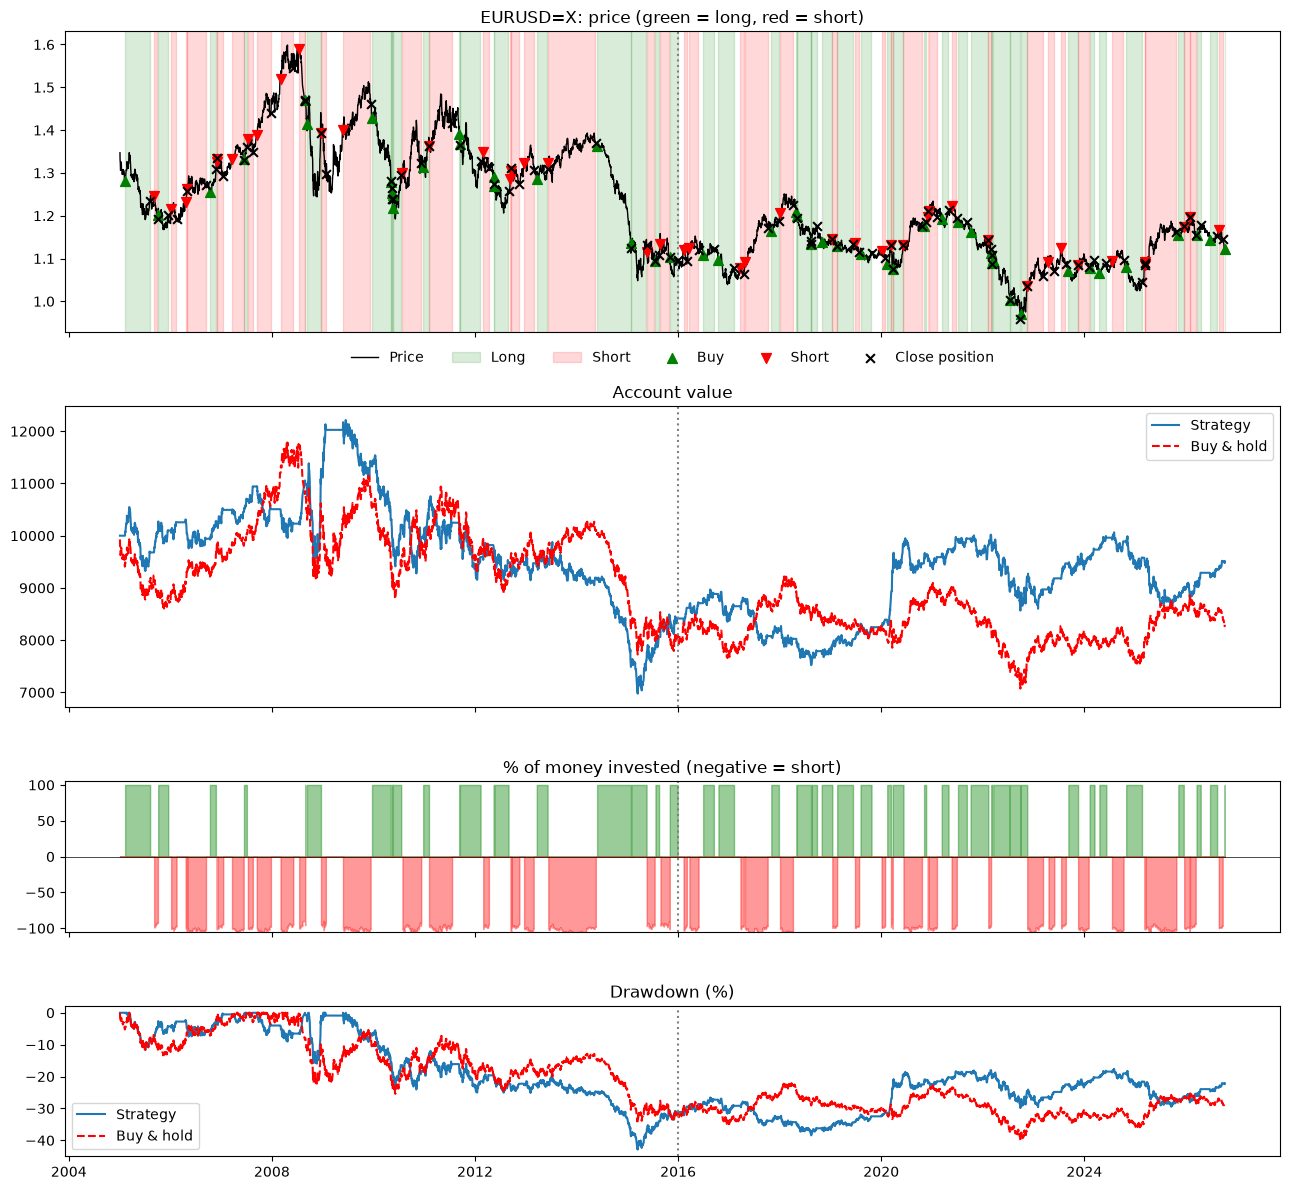

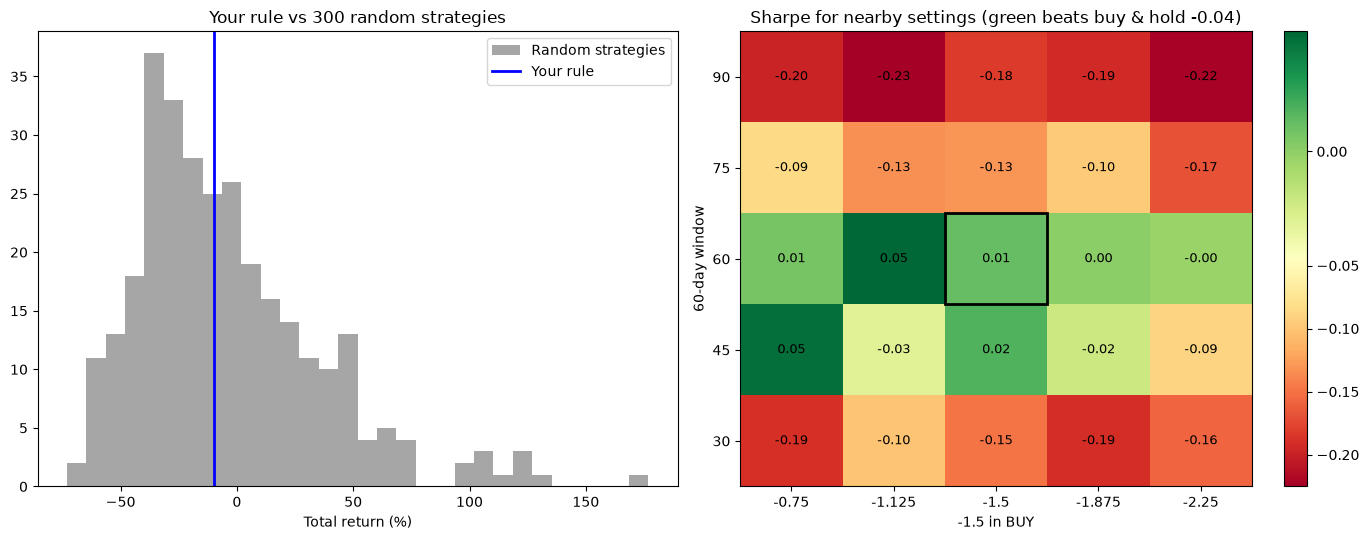

In [14]:
def _loading(done, total):
    if total > DOWNLOAD_CHUNK:
        print(f"  {done} of {total} loaded")


def run_study(tickers, start, end, settings, split_date, advanced, portfolio=False, allocation="smart",
              max_weight_pct=None, compare_sp500=False):
    # several tickers are tested one by one, each with the full starting money, or as one
    # portfolio that shares it. More than MAX_DETAILED tickers one by one get a quick backtest each
    portfolio = portfolio and len(tickers) > 1
    print_settings(tickers, start, end, settings, split_date, advanced, portfolio, allocation, max_weight_pct)
    print(f"\nLoading {', '.join(tickers) if len(tickers) <= 8 else str(len(tickers)) + ' tickers'}...")
    data, failed = load_many(tickers, start, end, _loading)
    for ticker, reason in failed:
        print(f"Skipped {ticker}: {reason}")
    sp500_fund = None
    if compare_sp500:
        try:
            sp500_fund = load_prices(SP500_FUND, start, end)
        except Exception as e:
            print(f"No S&P 500 comparison: {e}")
    if not data:
        return

    if portfolio:
        try:
            r = analyse_portfolio(data, start, end, settings, split_date, advanced, allocation, max_weight_pct,
                                  sp500_fund)
        except Exception as e:
            print(f"The portfolio could not be tested: {e}")
            return
        name = f"Portfolio of {len(r['full']['tickers'])} tickers"
        print_data_notes(r)
        if print_rule_check(name, r, settings):
            print_report(name, r)
            print_shares(r)
            print_per_ticker(r)
        print_verdict(r)
        plot_portfolio(r, split_date)
        plt.show()
        return

    if len(data) > MAX_DETAILED:
        table, skipped = scan_tickers(data, start, end, settings)
        print_scan(table, skipped)
        if not table.empty:
            plot_scan(table)
            plt.show()
            print("\nFor the full checks on one of them, run it again with just that ticker.")
        return

    rows = []
    for ticker, prices in data.items():
        try:
            r = analyse_ticker(prices, start, end, settings, split_date, advanced, sp500_fund)
        except Exception as e:
            print(f"Skipped {ticker}: {e}")
            continue

        print_data_notes(r)
        traded = print_rule_check(ticker, r, settings)
        print_report(ticker, r)
        if traded:
            print_breakdown(r)
        print_improvement(r["variants"])
        print_verdict(r)

        plot_results(ticker, r, split_date, compact=not advanced)
        if advanced:
            plot_checks(ticker, r)
        plt.show()
        rows.append(summary_row(ticker, r))

    if rows:
        print_summary(rows)


def default_cover(short_rule):
    return re.sub(r"^SHORT", "COVER", flip_rule(short_rule))


def custom_study():
    print(HELP)
    d = s = CUSTOM_DEFAULTS
    advanced = ask("Mode (q = quick, a = advanced)", "q", lambda t: t.lower().startswith("a"))
    tickers = ask("Tickers (e.g. EURUSD=X, SPY, AAPL, or a list: FOREX, FOREX28, SP500)",
                  ", ".join(d["tickers"]), as_some_tickers)
    portfolio = len(tickers) > 1 and ask("Test each ticker on its own, or all as one portfolio (o/p)", "o",
                                         lambda t: t.lower().startswith("p"))
    start = ask("Start date (YYYY-MM-DD)", d["start"], as_date)
    end = ask("End date (YYYY-MM-DD)", date.today().isoformat(), as_date)
    settings = {
        "buy_rule": ask("Buy rule (e.g. BUY IF PRICE > MA200)", s["buy_rule"], validate_rule),
        "sell_rule": ask("Sell rule (e.g. SELL IF PRICE < MA200)", s["sell_rule"], validate_rule),
    }

    if advanced:
        wants_short = ask("Shorting (y/n)", "y" if s["short_rule"] else "n", as_yes)
        short_rule = ask("Short rule (e.g. SHORT IF PRICE < MA200)", s["short_rule"], validate_rule) if wants_short else ""
    else:
        short_rule = ask("Short rule (e.g. SHORT IF PRICE < MA200, blank for none)", "", validate_rule)
    if parse_rule(short_rule) is not None:
        settings["short_rule"] = short_rule
        settings["cover_rule"] = ask("Cover rule (e.g. COVER IF PRICE > MA200)", default_cover(short_rule), validate_rule)
    else:
        settings.update({"short_rule": "", "cover_rule": ""})

    settings["cost_pct"] = ask("Cost per trade % (e.g. 0.02 for FX, 0.1 for stocks)", s["cost_pct"], as_non_negative)
    compare_sp500 = ask("Compare to the S&P 500 (y/n)", "n", as_yes)

    split_date = max_weight_pct = None
    allocation = "smart"
    if advanced:
        if portfolio:
            allocation = ask("Split the money (s = the app decides from the rule's record, e = an equal slice each, "
                             "o = over open positions)", "s", as_split)
            if allocation != "equal":
                max_weight_pct = ask("Most % in one ticker (blank = automatic)", "", as_optional_positive)
        settings.update({
            "short_fee_pct": (ask("Borrow fee % per year (e.g. 0 for FX, 0.5 for stocks)",
                                  s["short_fee_pct"], as_non_negative) if settings["short_rule"] else 0.0),
            "carry_pct": ask("Carry % per year: earned when long, paid when short (0 for stocks, for a currency "
                             "pair the first currency's interest rate minus the second's)", s["carry_pct"], float),
            "cash_rate_pct": ask("Interest on cash % per year (e.g. 0)", s["cash_rate_pct"], as_non_negative),
            "size_rule": ask("Size rule (e.g. SIZE BY RSI14 FROM 40 TO 20, blank for none)", "", validate_size),
            "initial": ask("Starting money (e.g. 10000)", s["initial"], as_positive),
            "position_pct": ask("Max % invested (e.g. 100)", s["position_pct"], as_positive),
            "target_vol_pct": ask("Target volatility % (e.g. 15, blank for none)", "", as_optional_positive),
            "rebalance_pct": ask("Rebalance band % (e.g. 10)", s["rebalance_pct"], as_non_negative),
            "stop_loss_pct": ask("Stop loss % (e.g. 5, blank for none)", "", as_optional_positive),
            "take_profit_pct": ask("Take profit % (e.g. 10, blank for none)", "", as_optional_positive),
        })
        split_date = ask("Train/test split date (YYYY-MM-DD, or none)", d["split_date"], as_optional_date)
        if split_date and not (start < split_date < end):
            print("Split date is outside the test window, so no split.")
            split_date = None
    else:
        settings.update(QUICK_DEFAULTS)
        print("\nOther settings use defaults (10,000 starting money, fully invested, no stops).")

    run_study(tickers, start, end, settings, split_date, advanced, portfolio, allocation, max_weight_pct, compare_sp500)


def main():
    print(f"Backtester v{__version__}")
    print(DEFAULT_STUDY["physics"])
    choice = input("\nEnter to run the pendulum study, or C for your own rules: ").strip().upper()
    if choice.startswith("C"):
        custom_study()
    else:
        d = DEFAULT_STUDY
        run_study(d["tickers"], d["start"], d["end"], dict(d["settings"]), d["split_date"], advanced=True)


main()